#### Words to start this notebook
* bit supprised there're some interesting codes for this Math 4 Machine Learning Specialization
* so, I'll move the SymPy Timbits here, and add along more

>Better to focuse on Engineering, or `What are we doing here`
* note for mar-16-2026, constantly run into this, and contantly forget this.
| Quantity                     | Formula                                                                                          | Meaning               |
| ---------------------------- | ------------------------------------------------------------------------------------------------ | --------------------- |
| Pearson correlation          | $\rho = \dfrac{\operatorname{Cov}(x,y)}{\sqrt {\operatorname{Var}(x)\operatorname{Var}(y)}} $  | linear association    |
| Coefficient of determination | $R^2 =\dfrac{\operatorname{Cov}(x,y)}{\operatorname{Var}(x)} \cdot \dfrac{\operatorname{Cov}(x,y)}{\operatorname{Var}(y)} $   | variance explained    |
| OLS slope formula  |$m = \dfrac{\operatorname{Cov}(x,y)}{\operatorname{Var}(x)}$  | slope of regression |



### Feb-25-2026

#### Use SymPy to get the Latex Code

In [2]:
import sympy as sp

M = sp.Matrix([[3,6,2,1,0,0],
               [10,3,8,0,1,0],
               [1,7,5,0,0,1]])

print(sp.latex(M))

#perform the Gaussian Elimination (rref(): Reduced Row Echelon Form)
# rref() returns a tuple: (the matrix, the indices of pivot columns)
m_rref, pivots = M.rref()

print(sp.latex(m_rref))

\left[\begin{matrix}3 & 6 & 2 & 1 & 0 & 0\\10 & 3 & 8 & 0 & 1 & 0\\1 & 7 & 5 & 0 & 0 & 1\end{matrix}\right]
\left[\begin{matrix}1 & 0 & 0 & \frac{41}{241} & \frac{16}{241} & - \frac{42}{241}\\0 & 1 & 0 & \frac{42}{241} & - \frac{13}{241} & \frac{4}{241}\\0 & 0 & 1 & - \frac{67}{241} & \frac{15}{241} & \frac{51}{241}\end{matrix}\right]


Copy the printed output from above into this Markdow cell here:

$$\left[\begin{matrix}3 & 6 & 2 & 1 & 0 & 0\\10 & 3 & 8 & 0 & 1 & 0\\1 & 7 & 5 & 0 & 0 & 1\end{matrix}\right]$$

Since this is an augmented matrix (used for finding an inverse), we'll add a vertical bar between the two halves using the array environment:
$$\left[\begin{array}{ccc|ccc} 3 & 6 & 2 & 1 & 0 & 0 \\ 10 & 3 & 8 & 0 & 1 & 0 \\ 1 & 7 & 5 & 0 & 0 & 1 \end{array}\right]$$

Perform the Gaussian Elimination:
$$\left[\begin{matrix}1 & 0 & 0 & \frac{41}{241} & \frac{16}{241} & - \frac{42}{241}\\0 & 1 & 0 & \frac{42}{241} & - \frac{13}{241} & \frac{4}{241}\\0 & 0 & 1 & - \frac{67}{241} & \frac{15}{241} & \frac{51}{241}\end{matrix}\right]$$

#### Understanding Gaussian Elimination
So the Gaussian Eliminiation $\left[ A \mid I \right] \xrightarrow{E_n \cdots E_1} \left[ I \mid A^{-1} \right]$ for $A \cdot B = I$ is just this
* step 1, with elementary matrix $E_1 = \begin{bmatrix} 1 & 0 & 0 \\ -1 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$, $E_1 \cdot A \cdot B = E_1 \cdot I$
  * note that Type 1: Replacement Matrix: $E_1$
  * demo, $A = \begin{bmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \\ 7 & 8 & 9 \end{bmatrix}$
  * $E_1 \cdot A = \begin{bmatrix} 1 & 2 & 3 \\ 3 & 3 & 3 \\ 7 & 8 & 9 \end{bmatrix}$, is the same of row_2_A minus row_1_A.
* step 2, remember that the dot product is not commutative, so the order is $E_n \cdots E_2 \cdot E_1 \cdot A \cdot B = E_n \cdot ⋯ E_2 \cdot E_1 \cdot I$
* repeat with different $E_i$ until $(\displaystyle \prod_{i=n}^1E_i \cdot A) \cdot B = \prod_{i=n}^1E_i \cdot I$, where $\displaystyle \prod_{i=n}^1E_i \cdot A = I$ and $\displaystyle \prod_{i=n}^1E_i \cdot I = B$


#### Use Sympy to solve a linear system
* With this linear system, find the value of $x, y, z$ with Gaussian Elimination
  * Note use (rref(): Reduced Row Echelon Form) from Sympy
* $x + y + z = 15$
* $3x + 2y + z = 28$
* $2x + y + 2z = 23$
* To solve the system using SymPy, we represent the weights in matrix $A$ and the constants in vector $b$. The augmented matrix $[A|b]$ looks like this:
$$
\left[
\begin{array}{ccc|c}
1 & 1 & 1 & 15 \\
3 & 2 & 1 & 28 \\
2 & 1 & 2 & 23
\end{array}
\right]
$$

In [5]:
# set out the weight matrix
# i.e., x + y + z = 15, means the first row of the matrix is [1, 1, 1]
A = sp.Matrix([[1, 1, 1],
               [3, 2, 1],
               [2, 1, 2]])

# set out the constants vector
# same i.e., x + y + z = 15, means the first componenet of the vector is 15
b = sp.Matrix([15, 28, 23])

# link them together, and check the output matrix
augumented_A_b = A.row_join(b)
augumented_A_b

Matrix([
[1, 1, 1, 15],
[3, 2, 1, 28],
[2, 1, 2, 23]])

In [4]:
#  use (rref(): Reduced Row Echelon Form) from Sympy to solve this linear system
echelon_form, pivots = augumented_A_b.rref()

# check the reduced form
echelon_form

Matrix([
[1, 0, 0, 3],
[0, 1, 0, 7],
[0, 0, 1, 5]])

Interpreting the rows of the `echelon_form`, here's the result:
* Row 1: $1x + 0y + 0z = 3$ thus,$x = 3$
* Row 2: $0x + 1y + 0z = 7$ thus,$y = 7$
* Row 3: $0x + 0y + 1z = 5$ thus,$z = 5$

#### SymPy's Rational is an advantage:
* No Rounding Errors: Standard Python floats would give you 1.1666666666666665. SymPy keeps it as an exact fraction: 7/6.
* Symbolic Integrity: In your RREF calculations from earlier, this is why you get results like 41/241, instead of messy decimals.
* Automatic Simplification: If you did Rational(2, 4), SymPy would automatically store it as 1/2.
* Pro Tip: You can also use the shortcut `sp.S()` (the sympify function) to write fractions more naturally:

In [7]:
#from sympy import Rational
x = Rational(1, 2)
y = Rational(2, 3)

print(x+y)

print(sp.S(1)/2 + sp.S(2)/3)

7/6
,7/6


#### SymPy's most powerful features: symbolic manipulation

In [8]:
a,b,c,d,e,f = sp.symbols("m_{11} m_{12} m_{21} m_{22} m_{31} m_{32}")
M = sp.Matrix([[a,b],
               [c,d],
               [e,f]])
M

Matrix([
[m_{11}, m_{12}],
[m_{21}, m_{22}],
[m_{31}, m_{32}]])

In [9]:
#alternate M_inv_alt = M-1

M[:2, :].inv()

Matrix([
[ m_{22}/(m_{11}*m_{22} - m_{12}*m_{21}), -m_{12}/(m_{11}*m_{22} - m_{12}*m_{21})],
[-m_{21}/(m_{11}*m_{22} - m_{12}*m_{21}),  m_{11}/(m_{11}*m_{22} - m_{12}*m_{21})]])

In [10]:
M.T

Matrix([
[m_{11}, m_{21}, m_{31}],
[m_{12}, m_{22}, m_{32}]])

In [11]:
M.T@M

Matrix([
[            m_{11}**2 + m_{21}**2 + m_{31}**2, m_{11}*m_{12} + m_{21}*m_{22} + m_{31}*m_{32}],
[m_{11}*m_{12} + m_{21}*m_{22} + m_{31}*m_{32},             m_{12}**2 + m_{22}**2 + m_{32}**2]])

#### SymPy to solve Eigenvector

In [12]:
m = sp.Matrix([[9, 9, -7],[3, -2, -9],[6, 0, 1]])
v = sp.Matrix([6, 3, -10])

m.LUsolve(v)

Matrix([
[-911/615],
[ 263/205],
[-228/205]])

#### Check if 3 vectors are linear independent
* check if $\det \begin{vmatrix} a \\ b \\ c \end{vmatrix} = 0 \Rightarrow \text{linearly dependent}$

In [13]:
a = [1, 2, -1]
b = [3, -4, 5]
c = [1, -8, 7]

X = np.array([a, b, c])

np.linalg.det(X)

np.float64(0.0)

#### Helper funciton to show the dot product components

In [14]:
def matrix_dot_product(A, B):
    if A.shape[1] != B.shape[0]:
        raise ValueError("Inner dimensions must match.")

    result = np.zeros((A.shape[0], B.shape[1]), dtype=float)
    step = np.empty((A.shape[0], B.shape[1]), dtype=object)
    step[:] = ""  # initialize empty strings

    for i in range(A.shape[0]):
        for j in range(B.shape[1]):
            parts = []
            for k in range(A.shape[1]):
                result[i, j] += A[i, k] * B[k, j]
                parts.append(f"({A[i, k]} * {B[k, j]})")
            step[i, j] = " + ".join(parts)

    return step, result

    
# Example usage with two 10x10 matrices
x = np.arange(0, 10)
matrix_a = np.vstack([np.full(10, 100), 10 * x, x2])
matrix_b = matrix_a.T

for i in range(matrix_a.shape[0]):
    for j in range(matrix_b.shape[1]):
        print('component', i+1, ',', j+1)
        #print(matrix_dot_product(matrix_a, matrix_b)[0][i][j])

print('\n the result:')
print(matrix_dot_product(matrix_a, matrix_b)[1])

component 1 , 1
,component 1 , 2
,component 1 , 3
,component 2 , 1
,component 2 , 2
,component 2 , 3
,component 3 , 1
,component 3 , 2
,component 3 , 3
,
, the result:
,[[100000.  45000.  28500.]
, [ 45000.  28500.  20250.]
, [ 28500.  20250.  15333.]]


#### Understanding `Transformation in a Plane or othe Object`
* It means you are applying a mathematical rule (the matrix) to the coordinates of every point that makes up that plane or object.
* $r' = ET_EE^{-1} \cdot r$
  * note, both $r$ and $r'$ are in Standard Space.
  * first, transform $r$ into the $E$ space, with $E^{-1}r$
  * second, apply the Transformation Matrix $T_E$, with $T_E (E^{-1}r)$
  * finally, transform them back to the Standard Space, with $E(T_EE^{-1}r)$
* note, if $E$ is orthonormal, $E^{-1} = E^T$, $E^T$ for faster and more stable computation.
* Equivalently (often the more common direction):$T_E = E^{-1} T E$
  * which says: take the standard-basis matrix $T$ and express it in the $E$-basis.

#### Understanding Gram-Schmidt process for constructing and orthonormal basis
* gsBasis(A) returns a matrix B whose columns are the Gram–Schmidt orthonormalized columns of A (often called Q).
* B is a function of A, but not not a scalar multiple of A: $B \ne \lambda A$
* example:

Let
$$
A=\begin{bmatrix}1&1\\0&1\end{bmatrix}
\quad(\text{columns } a_1=(1,0)^T,\ a_2=(1,1)^T).
$$
Gram–Schmidt gives
$$
b_1=\frac{a_1}{\|a_1\|}=(1,0)^T,\qquad
b_2=\frac{a_2-(a_2\cdot b_1)b_1}{\|a_2-(a_2\cdot b_1)b_1\|}
=\frac{(1,1)-(1)(1,0)}{\|(0,1)\|}=(0,1)^T.
$$
So
$$
B=\begin{bmatrix}1&0\\0&1\end{bmatrix}=I.
$$
There is no scalar $\lambda$ such that $I=\lambda A$ (since that would require $\lambda a_2 = e_2$, but $\lambda(1,1)$ can’t equal $(0,1)$).

Special case: if the columns of $A$ are already orthogonal, then GS just normalizes each column—still not a single scalar $\lambda$ unless all columns have the same norm (and no sign flips).

In [15]:
def gsBasis(A) :
    B = np.array(A, dtype=np.float64) # Make B as a copy of A, since we're going to alter it's values.
    # Loop over all vectors, starting with zero, label them with i
    for i in range(B.shape[1]) :
        # Inside that loop, loop over all previous vectors, j, to subtract.
        for j in range(i) :
            # Complete the code to subtract the overlap with previous vectors.
            # you'll need the current vector B[:, i] and a previous vector B[:, j]
            # if i=0, jump right to the next step
            B[:, i] = B[:, i] - B[:, i] @ B[:, j] * B[:, j]
        
        # Next insert code to do the normalisation test for B[:, i]       
        if la.norm(B[:, i]) > verySmallNumber:
            B[:, i] = B[:, i] / la.norm(B[:, i])
        else:
            B[:, i] = 0
    return B

### Feb-26-2026

#### Understanding the Parallelogram in Standard Basis
* To draw a parallelogram in the standard space, from a matrix  $M = \left[\begin{matrix}a & b\\c & d\end{matrix}\right]$
* first, get matrix-vector multiplication to find the images of the basis vectors:
$$M \cdot e_1 = \left[\begin{matrix}a & b\\c & d\end{matrix}\right] \cdot \left[\begin{matrix}1\\0\end{matrix}\right] = \left[\begin{matrix}a\\c\end{matrix}\right]$$
$$M \cdot e_2 = \left[\begin{matrix}a & b\\c & d\end{matrix}\right] \cdot \left[\begin{matrix}0\\1\end{matrix}\right] = \left[\begin{matrix}b\\d\end{matrix}\right]$$
* second, draw each new projected vectors in the standard space as adjcent sides of the parallelogram
* and, $Area = |ad - bc|$

In [16]:
#to get the Latex
a,b,c,d = sp.symbols("a b c d")
M = sp.Matrix([[a,b],
               [c,d]])
print(sp.latex(M))

e1 = sp.Matrix([1, 0])
print(sp.latex(e1))

\left[\begin{matrix}a & b\\c & d\end{matrix}\right]
,\left[\begin{matrix}1\\0\end{matrix}\right]


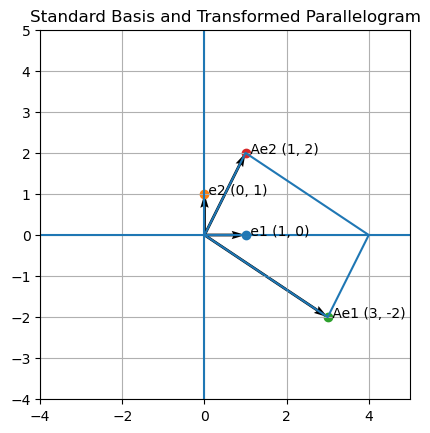

In [17]:
#import numpy as np
#import matplotlib.pyplot as plt

# Matrix A
A = np.array([[3, 1],
              [-2, 2]])

# Standard basis vectors
e1 = np.array([1, 0])
e2 = np.array([0, 1])

# Transformed basis vectors
Ae1 = A @ e1
Ae2 = A @ e2

plt.figure()
plt.axhline(0)
plt.axvline(0)

# Plot vectors
plt.quiver(0, 0, e1[0], e1[1], angles='xy', scale_units='xy', scale=1)
plt.quiver(0, 0, e2[0], e2[1], angles='xy', scale_units='xy', scale=1)
plt.quiver(0, 0, Ae1[0], Ae1[1], angles='xy', scale_units='xy', scale=1)
plt.quiver(0, 0, Ae2[0], Ae2[1], angles='xy', scale_units='xy', scale=1)

# Mark vector tips with clean integers
vectors = {
    "e1": e1,
    "e2": e2,
    "Ae1": Ae1,
    "Ae2": Ae2
}

for label, vec in vectors.items():
    x, y = int(vec[0]), int(vec[1])  # Explicit cast to Python int
    plt.scatter(x, y)
    plt.text(x, y, f" {label} ({x}, {y})")

# Parallelogram
parallelogram = np.array([
    [0, 0],
    Ae1,
    Ae1 + Ae2,
    Ae2,
    [0, 0]
])

plt.plot(parallelogram[:, 0], parallelogram[:, 1])

plt.gca().set_aspect('equal', 'box')
plt.xlim(-4, 5)
plt.ylim(-4, 5)
plt.grid(True)
plt.title("Standard Basis and Transformed Parallelogram")

plt.show()

### Feb-27-2026

#### Understanding PageRank
1, The linkMatrix $L$

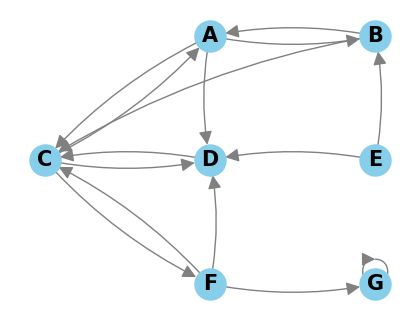

In [18]:
import networkx as nx
import matplotlib.pyplot as plt

# Create directed graph
G = nx.DiGraph()

# Nodes
nodes = ["A", "B", "C", "D", "E", "F", "G"]
G.add_nodes_from(nodes)

# Edges (based on the diagram)
edges = [("A", "B"), ("B", "A"),
         ("A", "C"), ("C", "A"),
         ("A", "D"),
         ("B", "C"),
         ("C", "D"), ("D", "C"),
         ("C", "F"), ("F", "C"),
         ("F", "D"),
         ("F", "G"),
         ("G", "G"),
         ("E", "B"),
         ("E", "D")]
G.add_edges_from(edges)

# Plot this Directed Graph, of our mini-internet
plt.figure(figsize=(4, 3))
pos = {"A": (1, 1), 
       "B": (2, 1), 
       "C": (0, 0), 
       "D": (1, 0), 
       "E": (2, 0), 
       "F": (1, -1), 
       "G": (2, -1)}
nx.draw(G, pos, with_labels=True, 
        node_color='skyblue', node_size=500, 
        edge_color='gray', arrowsize=20, 
        font_size=15, font_weight='bold',
        connectionstyle='arc3, rad = 0.1')

In [19]:
#import pandas as pd
#import networkx as nx

#Let's create a panda dataframe with both index and column names as A to G
#if there's A->B, then the value will be 1
# We specify the nodelist to ensure the order is A, B, C, D, E, F, G
nodes_order = ["A", "B", "C", "D", "E", "F", "G"]

# Convert the graph to a Pandas DataFrame
link_df = nx.to_pandas_adjacency(G, nodelist=nodes_order, dtype=int)
link_df

,A,B,C,D,E,F,G
A,0,1,1,1,0,0,0
B,1,0,1,0,0,0,0
C,1,0,0,1,0,1,0
D,0,0,1,0,0,0,0
E,0,1,0,1,0,0,0
F,0,0,1,1,0,0,1
G,0,0,0,0,0,0,1


In [20]:
#normalize each row, and transpose
link_df = link_df.div(link_df.sum(axis=1), axis=0).T

#convert to np.array as the linkMatrix
linkMatrix = link_df.to_numpy()

#linkMatrix is a bad mini-internet, as all traffic will be trapped in G
#we'll add a dumping facter d, if linkMatrix will be used

In [21]:
import numpy as np
import numpy.linalg as la

def pageRank(linkMatrix, d):
    n = linkMatrix.shape[0]
    
    # Create the Google Matrix
    M = d * linkMatrix + (1 - d) / n * np.ones((n, n))
    
    # Initialize the rank vector r, with 100 Pats
    r = 100 * np.ones(n) / n
    lastR = r
    r = M @ r
    i = 0
    while la.norm(lastR - r) > 0.01 :
        lastR = r
        r = M @ r
        i += 1
    
    print(str(i) + " iterations to convergence.")
    
    return r

# the sum of all components shoulbe 100 pat
np.sum(pageRank(linkMatrix, 0.7))

15 iterations to convergence.


np.float64(99.99999999999994)

In [22]:
def generate_internet(n) :
    """Generates a random n x n link matrix (stochastic matrix)."""
    # Create a coordinate grid for the matrix
    c = np.full([n,n], np.arange(n))
    
    # Use a Cauchy distribution to simulate the "power law" nature of internet links
    c = (abs(np.random.standard_cauchy([n,n])/2) > (np.abs(c - c.T) + 1)) + 0
    
    # Normalize the columns so they sum to 1 (making it a transition matrix)
    # Small epsilon (1e-10) is added to prevent division by zero
    c = (c+1e-10) / np.sum((c+1e-10), axis=0)
    
    return c

# Example usage: Generate a 5x5 "internet" and print it
L = generate_internet(3)
L

array([[3.33333333e-01, 3.33333333e-01, 1.00000000e-10],
       [3.33333333e-01, 3.33333333e-01, 1.00000000e+00],
       [3.33333333e-01, 3.33333333e-01, 1.00000000e-10]])

In [23]:
eVals, eVecs = np.linalg.eig(L) # Gets the eigenvalues and vectors

order = np.absolute(eVals).argsort()[::-1] # Orders them by their eigenvalues
eVals = eVals[order]
eVecs = eVecs[:,order]

principal_evec = np.real(eVecs[:, 0])
normalized_evec = principal_evec / np.sum(principal_evec)

la.norm(pageRank(L, 1) - normalized_evec) < 0.01


8 iterations to convergence.


np.False_

#### Formula Sheet for Linear Algebra

#### Vector Operations
1, Basic properties
  * $ r + s = s + r $
  * $ 2r = r + r $
  * $ |r|^2 = \sum_i r_i^2 $

2, Dot (Inner) Product $r \cdot s = \sum_i r_i s_i$

3, Properties:
* Commutative: $ r \cdot s = s \cdot r $
* Distributive: $ r \cdot (s+t) = r\cdot s + r\cdot t $
* Associative with scalar: $ r \cdot (a s) = a(r\cdot s) $
* Self-dot: $ r \cdot r = |r|^2 $
* Geometric meaning: $r\cdot s = |r|\,|s| \cos\theta$

4, Projections
* Scalar projection of $ s $ on $ r $: $\dfrac{r\cdot s}{|r|}$
* Vector projection of $ s $ on $ r $: $\dfrac{r\cdot s}{r\cdot r} \, r$

#### Basis
A set of $ n $ vectors is a basis if:
* They are linearly independent, `np.linalg.det(X) != 0`
* They span the space
* The space is then $ n $-dimensional.

#### Matrices
1, Matrix–vector multiplication 
* For $A = \begin{bmatrix} a & b \\ c & d \end{bmatrix} , \quad r = \begin{bmatrix} e \\ f \end{bmatrix}$, $\hspace{1cm} Ar = \begin{bmatrix} ae + bf \\ ce + df \end{bmatrix} $

2, Algebraic properties
* $ A(nr) = n(Ar) $
* $ A(r+s) = Ar + As $

3, Identity matrix
* $I = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} $

4, Rotation (clockwise) by angle $ \theta $
* $\begin{bmatrix} \cos\theta & \sin\theta \\ -\sin\theta & \cos\theta \end{bmatrix} $

5, Determinant of a 2×2 matrix
* $\det\begin{bmatrix} a & b \\ c & d \end{bmatrix} = ad - bc $

6, Inverse of a 2×2 matrix
* $\begin{bmatrix} a & b \\ c & d \end{bmatrix}^{-1}  = \frac{1}{ad - bc} \begin{bmatrix}
d & -b \\ -c & a \end{bmatrix} $

7, Matrix multiplication (Einstein summation convention)
* $(ab)_{ik} = \displaystyle \sum_j a_{ij} b_{jk}$

#### Change of Basis
Let $ B $ be the matrix whose columns are the new basis vectors expressed in the original basis.

Then converting coordinates:
* $Br' = r$
* $r' = B^{-1} r$

Orthonormal case: If $ A $ is orthonormal
* $A^T = A^{-1}$

#### Gram–Schmidt Process
Given linearly independent vectors $ v_1, v_2, \dots, v_n $:
* $e_1 = \frac{v_1}{|v_1|}$
* $u_2 = v_2 - (v_2\cdot e_1)e_1, \quad e_2 = \frac{u_2}{|u_2|}$
* Continue similarly for $ v_3, v_4, \dots $
* refer to `Understanding Gram-Schmidt process for constructing and orthonormal basis`.

#### Transformation in a Plane (General Method)
To transform a vector ( r ):
* Transform into the basis of the object/plane:
  * $ E^{-1} $
  * note,
    * $Er' = r$
    * $r' = E^{-1} r$
* Apply the transformation in that basis:
  * $ T $
* Transform back:
  * $ E $
* Final result:
  * $ r' = E T E^{-1} r $

#### Eigenstuff
Eigenvalue equation
* $ Ax = \lambda x $

Equivalent to:
* $ (A - \lambda I)x = 0 $

Eigenvalues satisfy:
* $ \det(A - \lambda I) = 0 $

In [24]:
#for exmaple, a 4 by 4 matrix L
L = np.array([[1, 2, 3, 4], [2, 3, 4, 5], [3, 4, 5, 6], [4, 5, 6, 7]])

eVals, eVecs = np.linalg.eig(L) # Gets the eigenvalues and vectors

order = np.absolute(eVals).argsort()[::-1] # Orders them by their eigenvalues
eVals = eVals[order]
eVecs = eVecs[:,order]

r = eVecs[:, 0] # Sets r to be the principal eigenvector
r

array([-0.31472119, -0.42747244, -0.54022368, -0.65297493])

#### PageRank (Power Iteration Method)
Iterative update:
* $r_{i+1} = L r_i$

With damping factor $ d $
* $r_{i+1} = d L r_i + \frac{1-d}{n} $


### Mar-02-2026

#### Definition of a derivative

$f'(x) = \dfrac {f(x)}{dx} = \lim \limits_{\Delta x \to 0}  \dfrac {f(x + \Delta x) - f(x)}{\Delta x}$

#### Time saving heuristics rules
* Sum Rule: $ \dfrac{d}{dx} (f(x) + g(x)) = \dfrac{d}{dx} (f(x)) + \dfrac{d}{dx} (g(x)) $
* Power Rule:  Given $f(x) = ax^b$,  then $f'(x) = abx^{(b-1)}$
* Product Rule:  Given $A(x) = f(x)g(x)$,  then $A'(x) = f'(x)g(x) + f(x)g'(x)$
* Chain Rule:  Given $h = h(p)$ and $p = p(m)$,  then $ \dfrac{dh}{dm} = \dfrac{dh}{dp} \times \dfrac{dp}{dm} $

#### Total derivative:
For the function $f(x, y, z, ...)$, where each variable is a function of parameter $t$, the total derivative is

$$\frac{df}{dt} = \frac{\partial f}{\partial x} \frac{dx}{dt} + \frac{\partial f}{\partial y} \frac{dy}{dt} + \frac{\partial f}{\partial z} \frac{dz}{dt} + \dots$$

#### Understanding the Ordinary Derivative $\frac{d(y^2)}{dx}$ and the Partial Derivative $\frac {\partial (y^2)}{\partial x}$
Ordinary Derivative. 
* The Assumption: In the equation $\frac{d(y^2)}{dx}$, we assume $y$ is a function of $x$. When $x$ moves, $y$  must also move to stay on the circle.
* The Calculation uses the __chain rule__.$ \dfrac{d(y^2)}{dx}=\dfrac{d(y^2)}{dy}\dfrac{dy}{dx}=2y\dfrac{dy}{dx}. $

Partial Derivative
* The Assumption: $y$ is irrlevant to $x$ and treated as a __constant number__
* Thus, $\dfrac{\partial (y^2)}{\partial x}=0 $


#### Derivative structures
Given $f = f(x, y, z)$
* Jacobian:
$$\mathbf{J}_f = \left[ \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}, \frac{\partial f}{\partial z} \right]$$
* Hessian:
$$
H_f = \begin{bmatrix}
\frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} & \frac{\partial^2 f}{\partial x \partial z} \\
\frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2} & \frac{\partial^2 f}{\partial y \partial z} \\
\frac{\partial^2 f}{\partial z \partial x} & \frac{\partial^2 f}{\partial z \partial y} & \frac{\partial^2 f}{\partial z^2}
\end{bmatrix}
$$

In [2]:
import sympy as sp

x, y, z = sp.symbols('x y z')
f = x**2 * sp.cos(y) + sp.exp(z) * sp.sin(y)

# Wrap f in a Matrix to use the jacobian method
F = sp.Matrix([f])
J = F.jacobian((x, y, z))

# Define the point for evaluation
# Tip: Using a list of tuples is also a common way to pass multiple substitutions
point = [(x, sp.pi), (y, sp.pi), (z, 1)]

# Evaluate
f_val = f.subs(point)
J_eval = J.subs(point)

# Results
print(f"Jacobian Symbolic: {J}")
print(f"f at point: {f_val}")
print(f"J at point: {J_eval}")

# If you need decimal values:
print(f"J (decimal): {J_eval.evalf()}")



Jacobian Symbolic: Matrix([[2*x*cos(y), -x**2*sin(y) + exp(z)*cos(y), exp(z)*sin(y)]])
f at point: -pi**2
J at point: Matrix([[-2*pi, -E, 0]])
J (decimal): Matrix([[-6.28318530717959, -2.71828182845905, 0]])


In [4]:
import sympy as sp

x, y = sp.symbols('x y')
f1 = x**2 * y - sp.cos(x) * sp.sin(y)
f2 = sp.exp(x+y)

# 1. Create a Matrix of functions
F = sp.Matrix([f1, f2])

# 2. Compute the Jacobian
J = F.jacobian((x, y))

# 3. Evaluate at the point (0, pi)
point = {x: 0, y: sp.pi}
J_at_point = J.subs(point)

print("Jacobian Matrix:")
sp.pprint(J)
print("\nEvaluated at (0, pi):")
sp.pprint(J_at_point)




Jacobian Matrix:
⎡                        2                ⎤
⎢2⋅x⋅y + sin(x)⋅sin(y)  x  - cos(x)⋅cos(y)⎥
⎢                                         ⎥
⎢        x + y                 x + y      ⎥
⎣       ℯ                     ℯ           ⎦

Evaluated at (0, pi):
⎡0   1 ⎤
⎢      ⎥
⎢ π   π⎥
⎣ℯ   ℯ ⎦


In [6]:
import sympy as sp

x, y, z = sp.symbols('x y z')
f = x * y * sp.cos(z) - sp.sin(x) * sp.exp(y) * z**3

# Compute the Hessian
H = sp.hessian(f, (x, y, z))

# Define the evaluation point
point = {x: 0, y: 0, z: 0}

# Evaluate the Hessian at the point
H_at_origin = H.subs(point)

print("Hessian at (0, 0, 0):")
sp.pprint(H_at_origin)


Hessian at (0, 0, 0):
⎡0  1  0⎤
⎢       ⎥
⎢1  0  0⎥
⎢       ⎥
⎣0  0  0⎦


#### Neural networks
* Activation function:
$$\sigma(x) = \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

$$\frac{d}{dx}(\sigma(x)) = \frac{1}{\cosh^2(x)} = \frac{4}{(e^x + e^{-x})^2}$$

#### Taylor Series
* Univariate:
$$\begin{align*}
f(x) &= f(p) + f'(p)(x - p) + \frac{1}{2}f''(p)(x - p)^2 + \dots \\
     &= \sum_{n=0}^{\infty} \frac{f^{(n)}(p)}{n!}(x - p)^n
\end{align*}$$
* Univariate, connection with Derivation
$$f(x+\Delta x) = f(x) + f'(x)\Delta x + \frac{f''(x)}{2}\Delta x^2 + \frac{f^{(3)}(x)}{6}\Delta x^3 + \dots$$
$$f'(x) = \frac{f(x+\Delta x) - f(x))}{\Delta x} + O(\Delta x)$$

* Multivariate:
$$f(\mathbf{x}) = f(\mathbf{p}) + \mathbf{J}_f(\mathbf{p})(\mathbf{x} - \mathbf{p})+
\frac{1}{2}(\mathbf{x} - \mathbf{p})^T\mathbf{H}_f(\mathbf{p})(\mathbf{x} - \mathbf{p}) + ...$$

#### Optimization and Vector Calculus: Newton-Raphson, Lagrange Multipliers, Least Squares - $\chi ^2$ minimization
* Newton-Raphson:
$$x_{i+1} = x_i - \frac{f(x_i)}{f'(x_i)}$$
* Grad:
$$\nabla f = 
\begin{bmatrix}
    \frac{\partial f}{\partial x} \\
    \frac{\partial f}{\partial y} \\
    \frac{\partial f}{\partial z}
\end{bmatrix}$$
* Directional Gradient:
$$\nabla f \cdot \hat{r}$$
* Gradient Descent:
$$s_{n+1} = s_n - \gamma \nabla f$$
* Lagrange Multipliers $\lambda$:
$$\nabla f = \lambda \nabla g$$

* Least Squares - $\chi ^2$ minimization:
$$\chi^2 = \sum_{i=1}^{n} \frac{(y_i - y(x_i; a_k))^2}{\sigma_i^2}$$
* Criterion $$\nabla \chi^2 = 0$$
* Parameter Update Step
$$\begin{align*}
a_{next} &= a_{cur} - \gamma \nabla \chi^2 \\
&= a_{cur} + 2\gamma \sum_{i=1}^{n} \frac{(y_i - y(x_i; a_k))}{\sigma_i^2} \frac{\partial y}{\partial a_k}
\end{align*}$$


### Mar-05-2026

#### Simple Neuron Network: _Principia Mathematica de Structuris Nervorum Artificialium._
* Understanding the Sigmoid
  * `1 / (1 + np.exp(-x))`: This is the Logistic Sigmoid. It outputs values between 0 and 1. It is historically the "standard" sigmoid used to represent probabilities.
```python
  def sigmoid(x):
    return 1 / (1 + np.exp(-x))
```
  * `np.tanh`: This is the Hyperbolic Tangent. It outputs values between -1 and 1. It is essentially a scaled and shifted version of the logistic sigmoid.


In [9]:
import numpy as np
import pandas as pd

#we are trying to the network to give a NOT funciton
#that is, if you input 1, it returns 0. vice versa

#First, set the state of the network
sigmoid = np.tanh

#start with some noise, or random parameters
#w1 = 1.3
#b1 = -0.1

#Then, we define some function for the neuron activation.
def a1(a0, w1, b1):
    return sigmoid(w1 * a0 + b1)
x = 1

#Let's try some different weight and bias
w_list = [0, -3, 3, -5, 10]
b_list = [5, 0, 1, 5, 0]

# Generate results by iterating through zipped parameters
results = [{"Weight": w, "Bias": b, "Result": a1(x, w, b)} for w, b in zip(w_list, b_list)]

# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(results)
print(df.sort_values(by='Result', key=abs))

   Weight  Bias    Result
3      -5     5  0.000000
1      -3     0 -0.995055
2       3     1  0.999329
0       0     5  0.999909
4      10     0  1.000000


In [11]:
#start with some noise, or random parameters
w1 = 1.3
b1 = -0.1

#Then, we define some function for the neuron activation.
def a1(a0, w1, b1):
    return sigmoid(w1 * a0 + b1)
x = 0

(a1(x, w1, b1) - 1)**2

np.float64(1.209269698402472)

In [12]:
#3 to 2

#First we set up the network
sigma = np.tanh
W = np.array([[-2, 4, -1], [6, 0, -3]])
b = np.array([0.1, -2.5])

#Define the input vectors for a0_1, a0_2, a0_3
a0 = np.array([0.3, 0.4, 0.1])

#Then, we define some function for the neuron activation.
def a1(a0, W, b):
    return sigma(W @ a0 + b)

a1(a0, W, b)

array([ 0.76159416, -0.76159416])

In [13]:
sigma(W@a0 + b)

array([ 0.76159416, -0.76159416])

### Mar-06-2026

#### Backpropagation Demo, with a Layer(0)-to-Layer(3) Neural Network

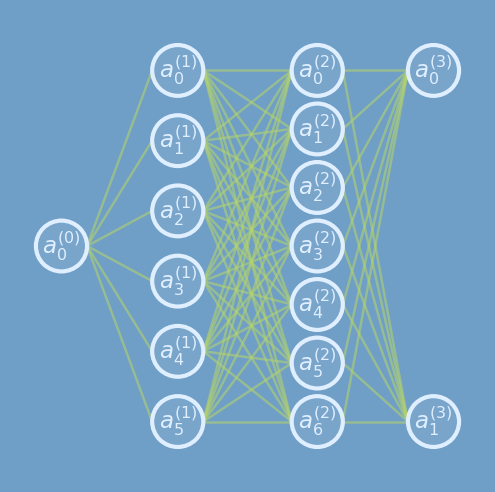

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# --------- layout (layers and nodes) ----------
layers = [1, 6, 7, 2]  # a^(0):1, a^(1):6, a^(2):7, a^(3):2
x_positions = [0.10, 0.35, 0.65, 0.90]

# (optional) labels to match your image style
def node_label(layer_idx, node_idx):
    return rf"$a_{{{node_idx}}}^{{({layer_idx})}}$"

# --------- style ----------
bg = "#6f9ec6"         # blue background
node_edge = "#dfefff"  # light ring
node_face = (1, 1, 1, 0.08)
edge_color = "#b6d56a" # yellow-green connections

r = 0.055  # node radius in axes coords

fig, ax = plt.subplots(figsize=(4, 4), dpi=150)
fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# --------- compute node positions ----------
positions = {}  # (layer_idx, node_idx) -> (x, y)
for li, (n, x) in enumerate(zip(layers, x_positions)):
    if n == 1:
        ys = [0.5]
    else:
        top, bottom = 0.88, 0.12
        ys = [top - i * (top - bottom) / (n - 1) for i in range(n)]
    for ni, y in enumerate(ys):
        positions[(li, ni)] = (x, y)

# --------- draw fully-connected edges between consecutive layers ----------
for li in range(len(layers) - 1):
    left_n = layers[li]
    right_n = layers[li + 1]
    for i in range(left_n):
        x1, y1 = positions[(li, i)]
        for j in range(right_n):
            x2, y2 = positions[(li + 1, j)]
            ax.plot([x1 + r, x2 - r], [y1, y2],
                    color=edge_color, lw=1.2, alpha=0.55, zorder=1)

# --------- draw nodes and labels ----------
for (li, ni), (x, y) in positions.items():
    c = Circle((x, y), r, facecolor=node_face, edgecolor=node_edge, lw=2.0, zorder=3)
    ax.add_patch(c)
    ax.text(x, y, node_label(li, ni), ha="center", va="center",
            color=node_edge, fontsize=11, zorder=4)

plt.show()


1-What's this Neural Network.
* Start with one input $\alpha_0^{(0)}$, outputs two coordinates $\alpha_0^{(3)}$ and $\alpha_1^{(3)}$;
* Draw $[\alpha_0^{(3)}, \alpha_1^{(3)}]$ on a X-Y axis to get a point.
* This above demo neural network has two hidden layers, make it
  * Input layer (L=0): 1 node $a_0^{(0)}$
  * Hidden layer 1 (L=1): 6 neurons $a_0^{(1)} \dots a_5^{(1)}$
  * Hidden layer 2 (L=2): 7 neurons $a_0^{(2)} \dots a_6^{(2)}$
  * Output layer (L=3): 2 neurons $a_0^{(3)}, a_1^{(3)}$


2-What's the demo plot from the trainning dataset $(x, y[y_0, y_1])$
* $x$: 100 even-spaced numbers from 0 to 1
* $y[y_0, y_1]$:
  * $y_0(x) = \frac{16\sin^3(2\pi x)}{20}$, and
  * $y_1(x) = \frac{13\cos(2\pi x)-5\cos(4\pi x)-2\cos(6\pi x)-\cos(8\pi x)}{20}$
  * The division by 20 just rescales the heart so it fits nicely in the plot.
  * `y = (y+1)/2` just relocate the heart from [-1, 1] to [0, 1] on the X-Y axis.
* Plot $[y_0, y_1])$ will give a heart-shaped curve.

(1, 100) (2, 100)


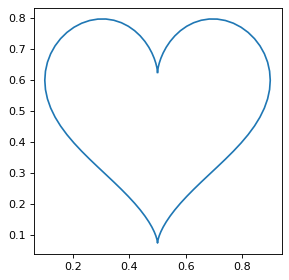

In [15]:
def training_data (N = 100) :
    x = np.arange(0,1,1/N)
    #the parametric heart curve:
    y = np.array([16*np.sin(2*np.pi*x)**3,
                  13*np.cos(2*np.pi*x) - 5*np.cos(2*2*np.pi*x) - 2*np.cos(3*2*np.pi*x)- np.cos(4*2*np.pi*x)
                 ])
    # devide by 20 to scale it smaller
    y = y / 20
    # relocate the heart to [0, 1] on the X-Y axis
    y = (y+1)/2

    # turn x to a 1 by 100 np.array
    x = np.reshape(x, (1, N))
    return x, y

x, y = training_data (N = 100)
print(x.shape, y.shape)

#plot the parametric heart curve
plt.figure(figsize=(4, 4), dpi= 80)
plt.plot(y[0], y[1])
plt.show()


3-What does this neural network do.
>The core intuition of supervised learning. At its heart, whether you are using a simple linear regression or a massive neural network, you are performing function approximation: $\hat y = f(x) + \epsilon$
* This neural network would learn from a trainning dataset $(x, y[y_0, y_1])$, to output coordinates $[\alpha_0^{(3)}, \alpha_1^{(3)}]$
  * This is just to mimic those two complicated functions of $y_0(x)$, and $y_1(x)$
  * Linear Regression, or Neural Network. We justing simulating a function from real world data, then use it to predict the unknown (inference).
* Draw 100 set of $[\alpha_0^{(3)}, \alpha_1^{(3)}]$ on a X-Y axis, they would produce a curve that's roughly close to a heart-shape.

4-What math are we practising with this neural network demo.
* the linear regression, $ \mathbf{z}^{(n)} = \mathbf{W}^{(n)}\mathbf{a}^{(n-1)} + \mathbf{b}^{(n)} $
* the activation function, $ \mathbf{a}^{(n)} = \sigma(\mathbf{z}^{(n)}) $
* the logistic function, $ \sigma(\mathbf{z}) = \dfrac{1}{1 + \exp(-\mathbf{z})} $
* Because the output layer has 2 neurons, the squared-error cost becomes

$$C =
\frac{1}{n}
\left(
(a_0^{(3)} - y_0)^2 +
(a_1^{(3)} - y_1)^2
\right)
$$
* Equivalently, the cost in Vector Form

$$
C =
\frac{1}{n}
|\alpha^{(3)} - y|^2
$$

* as shown in the codes below
```python
np.linalg.norm(network_function(x)[-1] - y)**2 / x.size
```

In [17]:
# Here is the activation function and its derivative.
sigma = lambda z : 1 / (1 + np.exp(-z))
d_sigma = lambda z : np.cosh(z/2)**(-2) / 4

# This function initialises the network with it's structure, it also resets any training already done.
def reset_network (n1 = 6, n2 = 7, random=np.random) :
    global W1, W2, W3, b1, b2, b3
    # random.randn() generates random numbers from a Standard Normal Distribution.
    W1 = random.randn(n1, 1) / 2
    W2 = random.randn(n2, n1) / 2
    W3 = random.randn(2, n2) / 2
    b1 = random.randn(n1, 1) / 2
    b2 = random.randn(n2, 1) / 2
    b3 = random.randn(2, 1) / 2

# This function feeds forward each activation to the next layer. It returns all weighted sums and activations.
def network_function(a0) :
    z1 = W1 @ a0 + b1
    a1 = sigma(z1)
    z2 = W2 @ a1 + b2
    a2 = sigma(z2)
    z3 = W3 @ a2 + b3
    a3 = sigma(z3)
    return a0, z1, a1, z2, a2, z3, a3

# This is the cost function of a neural network with respect to a training set.
def cost(x, y) :
    return np.linalg.norm(network_function(x)[-1] - y)**2 / x.size

5-Understanding the Gradient Descent Process
* The training process is found the Weight $\mathbf W^{(n)}$ and bias $\mathbf b^{(n)}$ that produce the smallest Cost $C$
* The computer implements this training process with stochastic gradient descent–style update
* Let's take the Weight $\mathbf W^{(3)}$ from the 3rd layer for example
```python
j_W3 = J_W3(x, y) * (1 + np.random.randn() * noise)
W3 = W3 - j_W3 * aggression
```
* | Variable     | Meaning                        |
| ------------ | ------------------------------ |
| `J_W3(x, y)` | gradient of cost w.r.t. (W_3)  |
| `noise`      | scale of Gaussian perturbation, noise=1 |
| `aggression` | learning rate, aggression=3.5  |
* You calculated the J_W3(x, y), with the Chain Rule
$$ J_{W3}(x, y) = \frac{\partial C}{\partial \mathbf{W}^{(3)}} =
   \frac{\partial C}{\partial \mathbf{a}^{(3)}}
   \frac{\partial \mathbf{a}^{(3)}}{\partial \mathbf{z}^{(3)}}
   \frac{\partial \mathbf{z}^{(3)}}{\partial \mathbf{W}^{(3)}}$$

6-Let's break down this backpropagation chain rule calculation
$$ J_{W3}(x, y) = \frac{\partial C}{\partial \mathbf{W}^{(3)}} =
   \frac{\partial C}{\partial \mathbf{a}^{(3)}}
   \frac{\partial \mathbf{a}^{(3)}}{\partial \mathbf{z}^{(3)}}
   \frac{\partial \mathbf{z}^{(3)}}{\partial \mathbf{W}^{(3)}}$$
* with input a0=x, we generate some random weight and bias, and calcuate values in each layer
```python
a0, z1, a1, z2, a2, z3, a3 = network_function(x)
```
* then calculate each of the derivation in the chain rule
  * Firstly, we calculate  $\dfrac{\partial C}{\partial \mathbf{a}^{(3)}} = \dfrac{\partial (\mathbf{a}^{(3)} - y)^2 /n}{\partial \mathbf{a}^{(3)}} = \dfrac{2}{n} \, (\mathbf{a}^{(3)} - y)$
  * Next, calculate $\dfrac{\partial \mathbf{a}^{(3)}}{\partial \mathbf{z}^{(3)}} = \dfrac{\partial (sigma(\mathbf{z}^{(3)})}{\partial \mathbf{z}^{(3)}} = d\_sigma(\mathbf{z}^{(3)})$
  * Next, calculte $\dfrac{\partial \mathbf{z}^{(3)}}{\partial \mathbf{W}^{(3)}} =  \dfrac{\partial(\mathbf{W}^{(3)}\mathbf{a}^{(2)} + \mathbf{b}^{(3)})}{\partial \mathbf{W}^{(3)}} = \mathbf{a}^{(2)}$
  *  Last, chain rule them together $J_{W3}(x, y) = \dfrac{\partial C}{\partial \mathbf{W}^{(3)}} = \dfrac{2}{n} \, (\mathbf{a}^{(3)} - y) \cdot d\_sigma(\mathbf{z}^{(3)}) \cdot \mathbf{a}^{(2)}$


7-Expand the $ \mathbf{W}^{(3)}$ example to all
* $\mathbf{b}^{(3)}$
$$ \frac{\partial C}{\partial \mathbf{b}^{(3)}} =
   \frac{\partial C}{\partial \mathbf{a}^{(3)}}
   \frac{\partial \mathbf{a}^{(3)}}{\partial \mathbf{z}^{(3)}}
   \frac{\partial \mathbf{z}^{(3)}}{\partial \mathbf{b}^{(3)}}
   $$
* Layer 2
$$ \frac{\partial C}{\partial \mathbf{W}^{(2)}} =
   \frac{\partial C}{\partial \mathbf{a}^{(3)}}
   \left(
   \frac{\partial \mathbf{a}^{(3)}}{\partial \mathbf{a}^{(2)}}
   \right)
   \frac{\partial \mathbf{a}^{(2)}}{\partial \mathbf{z}^{(2)}}
   \frac{\partial \mathbf{z}^{(2)}}{\partial \mathbf{W}^{(2)}}
   $$
$$ \frac{\partial C}{\partial \mathbf{b}^{(2)}} =
   \frac{\partial C}{\partial \mathbf{a}^{(3)}}
   \left(
   \frac{\partial \mathbf{a}^{(3)}}{\partial \mathbf{a}^{(2)}}
   \right)
   \frac{\partial \mathbf{a}^{(2)}}{\partial \mathbf{z}^{(2)}}
   \frac{\partial \mathbf{z}^{(2)}}{\partial \mathbf{b}^{(2)}}
   $$
$$ \frac{\partial \mathbf{a}^{(3)}}{\partial \mathbf{a}^{(2)}} =
   \frac{\partial \mathbf{a}^{(3)}}{\partial \mathbf{z}^{(3)}}
   \frac{\partial \mathbf{z}^{(3)}}{\partial \mathbf{a}^{(2)}} =
   \sigma'(\mathbf{z}^{(3)})
   \mathbf{W}^{(3)}$$
* Layer 1
$$ \frac{\partial C}{\partial \mathbf{W}^{(1)}} =
   \frac{\partial C}{\partial \mathbf{a}^{(3)}}
   \left(
   \frac{\partial \mathbf{a}^{(3)}}{\partial \mathbf{a}^{(2)}}
   \frac{\partial \mathbf{a}^{(2)}}{\partial \mathbf{a}^{(1)}}
   \right)
   \frac{\partial \mathbf{a}^{(1)}}{\partial \mathbf{z}^{(1)}}
   \frac{\partial \mathbf{z}^{(1)}}{\partial \mathbf{W}^{(1)}}
   $$
$$ \frac{\partial C}{\partial \mathbf{b}^{(1)}} =
   \frac{\partial C}{\partial \mathbf{a}^{(3)}}
   \left(
   \frac{\partial \mathbf{a}^{(3)}}{\partial \mathbf{a}^{(2)}}
   \frac{\partial \mathbf{a}^{(2)}}{\partial \mathbf{a}^{(1)}}
   \right)
   \frac{\partial \mathbf{a}^{(1)}}{\partial \mathbf{z}^{(1)}}
   \frac{\partial \mathbf{z}^{(1)}}{\partial \mathbf{b}^{(1)}}
   $$

In [18]:
# code of the back-propagation
def J_W3 (x, y) :
    # First get all the activations and weighted sums at each layer of the network.
    a0, z1, a1, z2, a2, z3, a3 = network_function(x)
    # We'll use the variable J to store parts of our result as we go along, updating it in each line.
    # Firstly, we calculate dC/da3, using the expressions above.
    J = 2 * (a3 - y)
    # Next multiply the result we've calculated by the derivative of sigma, evaluated at z3.
    J = J * d_sigma(z3)
    # Then we take the dot product (along the axis that holds the training examples) with the final partial derivative,
    # i.e. dz3/dW3 = a2
    # and divide by the number of training examples, for the average over all training examples.
    J = J @ a2.T / x.size
    # Finally return the result out of the function.
    return J

def J_b3 (x, y) :
    # As last time, we'll first set up the activations.
    a0, z1, a1, z2, a2, z3, a3 = network_function(x)
    # Next you should implement the first two partial derivatives of the Jacobian.
    # ===COPY TWO LINES FROM THE PREVIOUS FUNCTION TO SET UP THE FIRST TWO JACOBIAN TERMS===
    J = 2 * (a3 - y)
    J = J * d_sigma(z3)
    # For the final line, we don't need to multiply by dz3/db3, because that is multiplying by 1.
    # We still need to sum over all training examples however.
    # There is no need to edit this line.
    J = np.sum(J, axis=1, keepdims=True) / x.size
    return J

def J_W2 (x, y) :
    #The first two lines are identical to in J_W3.
    a0, z1, a1, z2, a2, z3, a3 = network_function(x)    
    J = 2 * (a3 - y)
    # the next two lines implement da3/da2, first σ' and then W3.
    J = J * d_sigma(z3)
    J = (J.T @ W3).T
    # then the final lines are the same as in J_W3 but with the layer number bumped down.
    J = J * d_sigma(z2)
    J = J @ a1.T / x.size
    return J

def J_b2 (x, y) :
    a0, z1, a1, z2, a2, z3, a3 = network_function(x)
    J = 2 * (a3 - y)
    J = J * d_sigma(z3)
    J = (J.T @ W3).T
    # Apply the derivative of the activation function for layer 2
    J = J * d_sigma(z2)
    J = np.sum(J, axis=1, keepdims=True) / x.size
    return J

def J_W1 (x, y) :
    a0, z1, a1, z2, a2, z3, a3 = network_function(x)
    J = 2 * (a3 - y)
    J = J * d_sigma(z3)
    J = (J.T @ W3).T
    J = J * d_sigma(z2)
    # New step: Propagate back through Layer 2 weights
    J = (J.T @ W2).T 
    # New step: Multiply by the activation derivative of Layer 1
    J = J * d_sigma(z1)
    # The remaining lines were placeholders; the math is finished by:
    J = J @ a0.T / x.size
    return J

def J_b1 (x, y) :
    a0, z1, a1, z2, a2, z3, a3 = network_function(x)
    # Start from the output layer cost derivative
    J = 2 * (a3 - y)
    J = J * d_sigma(z3)
    # Propagate back to Layer 2
    J = (J.T @ W3).T
    J = J * d_sigma(z2)
    # Propagate back to Layer 1
    J = (J.T @ W2).T
    J = J * d_sigma(z1)
    # Sum the gradients across the batch for the bias
    J = np.sum(J, axis=1, keepdims=True) / x.size
    return J

8-lastly, let's train this demo neural network, to silumlate that two parametric heart funcitons.
* input  $\alpha_0^{(0)} = x$
* Do the Neural Network Thing, output
* $\alpha_0^{(3)} \approx y_0(x) = \frac{16\sin^3(2\pi x)}{20}$, and
* $\alpha_1^{(3)} \approx y_1(x) = \frac{13\cos(2\pi x)-5\cos(4\pi x)-2\cos(6\pi x)-\cos(8\pi x)}{20}$
* Draw $[\alpha_0^{(3)}, \alpha_1^{(3)}]$, to get a heart shape plot, well, more or less.

In [19]:
def plot_training(x, y, iterations=10000, aggression=3.5, noise=1):

    global W1, W2, W3, b1, b2, b3

    checkpoints = [100, 500, 1000, 5000, 10000]
    snapshots = {}

    for i in range(1, iterations + 1):
        j_W1 = J_W1(x, y) * (1 + np.random.randn() * noise)
        j_W2 = J_W2(x, y) * (1 + np.random.randn() * noise)
        j_W3 = J_W3(x, y) * (1 + np.random.randn() * noise)

        j_b1 = J_b1(x, y) * (1 + np.random.randn() * noise)
        j_b2 = J_b2(x, y) * (1 + np.random.randn() * noise)
        j_b3 = J_b3(x, y) * (1 + np.random.randn() * noise)

        W1 = W1 - j_W1 * aggression
        W2 = W2 - j_W2 * aggression
        W3 = W3 - j_W3 * aggression

        b1 = b1 - j_b1 * aggression
        b2 = b2 - j_b2 * aggression
        b3 = b3 - j_b3 * aggression

        if i in checkpoints:
            nf = network_function(x)[-1]
            snapshots[i] = nf.copy()

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    for ax, step in zip(axes, checkpoints):
        ax.set_xlim([0,1])
        ax.set_ylim([0,1])
        ax.set_aspect(1)

        ax.plot(y[0], y[1], lw=1.5)           # target heart
        nf = snapshots[step]
        ax.plot(nf[0], nf[1], lw=2)           # network output

        ax.set_title(f"iteration = {step}")

    plt.tight_layout()
    #plt.savefig("training_progress.png", dpi=300, bbox_inches="tight")
    plt.show()

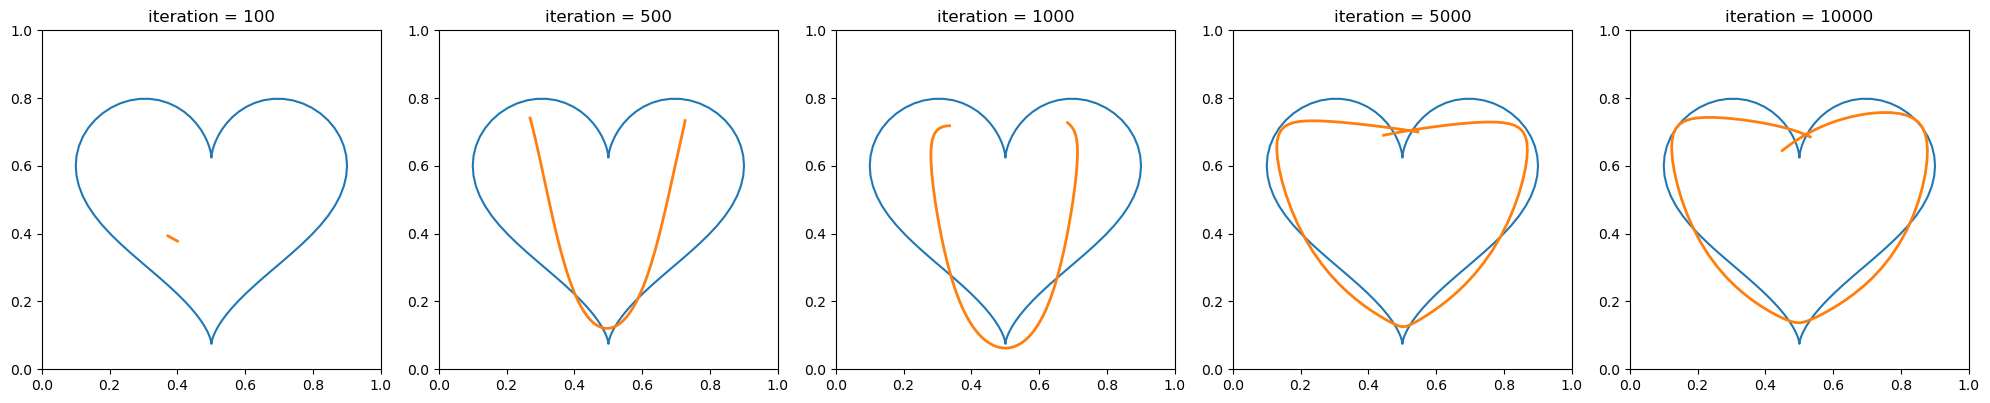

In [20]:
reset_network()
x, y = training_data()
plot_training(x, y, iterations=10000, aggression=7, noise=1)

### Mar-09-2026

#### Linearization: approximate to a linear function, omitting all the higher-order terms (nonlinear terms, or polynomial parts)
$$f(x+\Delta x) = f(x) + f'(x)\Delta x + \frac{f''(x)}{2}\Delta x^2 + \frac{f^{(3)}(x)}{6}\Delta x^3 + \dots = f(x) + f'(x)\Delta x + O(\Delta x^2)$$

First-order Taylor approximation
* By truncating the series after the first derivative term, we are essentially saying that for a sufficiently small change $\Delta x$, the curve of the function $f(x)$ can be treated as its tangent line at point $x$.
* The Linear Part: $f(x) + f'(x)\Delta x$ represents the equation of the tangent line.
* The Remainder: The term $O(\Delta x^2)$ (Big O notation) identifies that the error of this approximation shrinks at least/fast as the $\Delta x^2$. As $\Delta x \to 0$, this error becomes negligible compared to the linear terms.

#### Key Intuition: why Linearization
In data science, this Linearization is the "bread and butter" of simplifying complex systems. We are effectively replacing a jagged or curved landscape with a flat ramp that is much easier to compute.


#### Understanding $O(\Delta x^2)$.

Taylor series is an approximation of a known function, every extra term adds some more precision. Here's a demo to show the difference, between the second order and first order for $\ln(x) \approx \ln(10) + \frac{1}{10}(x-10) - \frac{1}{200}(x-10)^2$, for the value of $f(x)=\ln(x)$ when $x=2$
* The first three terms are $\ln(10)$, $\frac{1}{10}(x-10)$, and $- \frac{1}{200}(x-10)^2$
* The difference between the first order expansion at $p=10$, and second order expansion at $p=10$, is $- \frac{1}{200}(x-10)^2$.
* Plug in the value of $x=2$, $- \frac{1}{200}(x-10)^2 = - \frac{1}{200}(2-10)^2 = -64/200 = -0.32$


#### Understanding Power/Taylor/Maclaurin Series
| Term | Expansion Point ($p$) | Power Series Representation | Coefficient $c_n$ |
|---|---|---|---|
| Power Series (General) | Any point $p$ | $\displaystyle \sum_{n=0}^{\infty} c_n(x-p)^n$ | $c_n \in \mathrm R$ arbitary |
| Taylor Series | Any point $p$ | $\displaystyle \sum_{n=0}^{\infty} \frac{f^{(n)}(p)}{n!}(x-p)^n$ | $c_n=\dfrac{f^{(n)}(p)}{n!}$ |
| Maclaurin Series | Expand at the point $p = 0$ | $\displaystyle \sum_{n=0}^{\infty} \frac{f^{(n)}(0)}{n!}x^n$ | $c_n=\dfrac{f^{(n)}(0)}{n!}$ |


note
* If a point is not specified, it is standard practice to assume the expansion is around $p = 0$, the Maclaurin series
* $f(x) = \ln(x)$: Since $\ln(0)$ is undefined, it has no Maclaurin series. You must choose a point $p > 0$.
* $f(x) = \frac{1}{x}$: Similarly, this cannot be expanded around 0.

#### Taylor In SymPy
```python
x = sp.symbols('x')
f = sp.cos(x)
taylor = f.series(x, 0, 4)
```

Mathematically this means 
* $f(x) = a_0 + a_1 x + a_2 x^2 + a_3 x^3 + O(x^4)$
* highest explicit term → $x^3$
* remainder → $O(x^4)$, note `.removeO()`

Note this
* $\tan^{-1}(x) = \arctan(x)$, `sp.atan(x)`
* $tan(x)^{-1}$, `sp.tan(x)(-1) == sp.cot(x)`


#### Example: The Taylor series for $f(x) = \ln(x)$ expanded around the point $p = 10$

1,  Identify the General Formula for a Taylor series of a function
* $f(x)$ centered at a point $p$ is
$$f(x) = \sum_{n=0}^{\infty} f^{(n)} \cdot \frac{(p)}{n!} (x-p)^n$$
* For this problem, we set $f(x) = \ln(x)$ and $p = 10$.
$$f(x) = \sum_{n=0}^{\infty} (\ln(10))^{(n)} \cdot \frac{10}{n!} (x-10)^n$$

2, Compute the Derivatives
* $n=0$: $f(10) = \ln(10)$
* $n=1$: $f'(x) = \frac{1}{x} \implies f'(10) = \frac{1}{10}$
* $n=2$: $f''(x) = -\frac{1}{x^2} \implies f''(10) = -\frac{1}{100}$
* $n=3$: $f'''(x) = \frac{2}{x^3} \implies f'''(10) = \frac{2}{1000} = \frac{1}{500}$
* $n=4$: $f^{(4)}(x) = -\frac{6}{x^4} \implies f^{(4)}(10) = -\frac{6}{10000} = -\frac{3}{5000}$

3, Apply the Factorial Denominators
* Term 1: $\frac{1/10}{1!} (x-10)^1 = \frac{1}{10}(x-10)$
* Term 2: $\frac{-1/100}{2!} (x-10)^2 = -\frac{1}{200}(x-10)^2$
* Term 3: $\frac{2/1000}{3!} (x-10)^3 = \frac{2}{6000}(x-10)^3 = \frac{1}{3000}(x-10)^3$
* Term 4: $\frac{-6/10000}{4!} (x-10)^4 = -\frac{6}{240000}(x-10)^4 = -\frac{1}{40000}(x-10)^4$

4, Combine them together
$$\boxed{\ln(x) \approx \ln(10) + \frac{1}{10}(x-10) - \frac{1}{200}(x-10)^2 + \frac{1}{3000}(x-10)^3 - \frac{1}{40000}(x-10)^4 + \dots}$$

>1-Baisc Taylor Series, expand aroud x=0, thus MacLaurin

In [21]:
#import sympy as sp

x = sp.symbols('x')
f = sp.sin(x)

#Expand around x=0, thus the same with MacLaurin
taylor = f.series(x, 0, 10)
maclaurin = f.series(x, 0, 10).removeO()

print(taylor)
print(maclaurin)

x - x**3/6 + x**5/120 - x**7/5040 + x**9/362880 + O(x**10)
x**9/362880 - x**7/5040 + x**5/120 - x**3/6 + x


>2-To expand the Taylor series of $1/x$, around the point x = 4

In [22]:
# In order to keep the standard Taylor Notation
x = sp.symbols('x')
h = sp.symbols('h')
f = 1/x

# Taylor series, expand around the point x = 4
taylor = f.series(x, 4, 5)

# Point p = 4
p = 4

# Substitute x with (p + h) and expand around h = 0
taylor_h = f.subs(x, p + h).series(h, 0, 5)

# note,  h = (x - p)
# it can be switched
taylor_final = taylor_h.subs(h, x - p)

print(taylor)
print(taylor_h)
print(taylor_final)

1/2 + (x - 4)**2/64 - (x - 4)**3/256 + (x - 4)**4/1024 - x/16 + O((x - 4)**5, (x, 4))
1/4 - h/16 + h**2/64 - h**3/256 + h**4/1024 + O(h**5)
1/2 + (x - 4)**2/64 - (x - 4)**3/256 + (x - 4)**4/1024 - x/16 + O((x - 4)**5, (x, 4))


>3-To expand the Taylor series of $f(x) = \ln(x)$ around $x=10$ and find the difference at $x=2$: $\Delta f(x)$

In [23]:
#import sympy as sp

x = sp.symbols('x')
f = sp.log(x)

# 1. Expand around x=10. 
# Use order=2 for first-order polynomial, order=3 for second-order.
# .removeO() removes the Big-O notation so we can perform math on the result.
taylor_1 = f.series(x, 10, 2).removeO()
taylor_2 = f.series(x, 10, 3).removeO()

# 2. Evaluate both at x=2
val_1 = taylor_1.subs(x, 2)
val_2 = taylor_2.subs(x, 2)

# 3. Find the difference
difference = val_2 - val_1
print(f"Difference: {difference} (approx: {float(difference)})")

Difference: -8/25 (approx: -0.32)


#### To test if a function is even or odd using a Maclaurin series
you look at the powers of $x$ in the expansion:
* Even function: Only even powers ($x^0, x^2, x^4...$) appear.
* Odd function: Only odd powers ($x^1, x^3, x^5...$) appear.

For $f(x) = \tan^{-1}(x)$, the Maclaurin series (centered at $p=0$) is:
$$\tan^{-1}(x) = x - \frac{x^3}{3} + \frac{x^5}{5} - \frac{x^7}{7} + \dots$$
Since all powers are odd, the function is odd.

#### The symmetry definitions:
* Odd: $f(-x) = -f(x)$
* Even: $f(-x) = f(x)$
* For the case of $\tan^{-1}(x) = x - \frac{x^3}{3} + \frac{x^5}{5} - \frac{x^7}{7} + \dots$
  * If you plug $-x$ into the series $x - \frac{x^3}{3} + \dots$, every term flips its sign because the powers are odd.
  * This results in the entire expression becoming negative, proving $\tan^{-1}(-x) = -\tan^{-1}(x)$, thus the function is odd.


### Mar-11-2026

#### Shape of Multivariate Taylor Approximation for $f(x, y)$
For $f(x,y)$ expanded around $(a,b)$, it needs to be tangent to $(a, b)$, and with these shapes:
* Zeroth order (0th), $T_0(x,y)=f(a,b)$
  * Shape: a horizontal plane (constant surface) at height $z=f(a,b)$.
* First‑order (1st), $T_1(x,y)=f(a,b)+f_x(a,b)(x-a)+f_y(a,b)(y-b)$
  * Geometrically, this is a plane in 3D $(x,y,f)$ space: the tangent plane to the surface $z=f(x,y)$ at $(a,b,f(a,b))$.
* Second order (2nd), $T_2(x,y)=f(a,b)+f_x(a,b)(x-a)+f_y(a,b)(y-b)+\frac12\Big[f_{xx}(a,b)(x-a)^2+2f_{xy}(a,b)(x-a)(y-b)+f_{yy}(a,b)(y-b)^2\Big]$
  * Shape: a quadratic surface (a “paraboloid-type” surface). Depending on the Hessian (the $2\times2$ matrix of second derivatives).
  * Tangent: this quadratic surface matches the $f(x, y)$ value, slope, and curvature at point $(a, b)$.



#### Multi-variate Taylor in SymPy

In [24]:
x, y = sp.symbols('x y', real=True)
f = x2 - x*y - sp.sin(y)

mT1 = f.series(x, 0, 3).removeO().series(y, 0, 3).removeO()

mT1

y*(-x - 1) + 0.9

#### Hessian in SymPy

In [25]:
import sympy as sp

x, y = sp.symbols('x y', real=True)
f = sp.sin(sp.pi*x - x2*y)

H = sp.hessian(f, (x, y))
H_simplified = sp.simplify(H)

H

Matrix([
[-pi**2*sin(pi*x - 0.9*y), 0.9*pi*sin(pi*x - 0.9*y)],
[0.9*pi*sin(pi*x - 0.9*y),  -0.81*sin(pi*x - 0.9*y)]])

In [26]:
#Expand at point(1, pi)
H_at_ab = H_simplified.subs({x: 1, y: sp.pi})
H_at_ab

Matrix([
[-pi**2*sin(0.9*pi), 0.9*pi*sin(0.9*pi)],
[0.9*pi*sin(0.9*pi),  -0.81*sin(0.9*pi)]])

#### Plot of Taylor Expansion to the 6th order

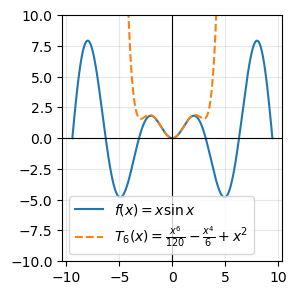

In [28]:
#import numpy as np
#import matplotlib.pyplot as plt
#import sympy as sp

# function and 3rd-order Taylor polynomial about 0
x = sp.Symbol('x')
f = x*sp.sin(x)
T6 = sp.series(f, x, 0, 7).removeO()   # up to x^3 terms

f_num  = sp.lambdify(x, f,  'numpy')
T6_num = sp.lambdify(x, T6, 'numpy')

xs = np.linspace(-3*np.pi, 3*np.pi, 1000)

plt.figure(figsize=(3,3))
plt.plot(xs, f_num(xs), label=r"$f(x)=x\sin x$")
plt.plot(xs, T6_num(xs), "--", label=rf"$T_6(x)={sp.latex(T6)}$")
plt.axhline(0, color="k", linewidth=0.8)
plt.axvline(0, color="k", linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.ylim(-10, 10)
plt.show()

#### General Multivariable Taylor Function

In [30]:
import sympy as sp
from itertools import product

def taylor_multi(f, vars, point, order):

    result = 0
    n = len(vars)

    for powers in product(range(order+1), repeat=n):

        if sum(powers) <= order:

            term = f
            factorial = 1

            for v, p in zip(vars, powers):
                term = sp.diff(term, v, p)
                factorial *= sp.factorial(p)

            term = term.subs(dict(zip(vars, point)))

            poly = 1
            for v, a, p in zip(vars, point, powers):
                poly *= (v - a)**p

            result += term * poly / factorial

    return sp.simplify(result)

In [32]:
#Test
x,y = sp.symbols('x y')

f = x*y2 * sp.exp(-x**4 - y**2/2)

taylor_multi(f, [x,y], [-1,2], 2)

1.0*(0.24*x**2 + 0.72*x*y - 1.32*x - 0.18*y**2 + 1.68*y - 2.88)*exp(-3)

### Mar-12-2026

#### Understanding Newton-Raphson: $x_{i+1} = x_i - \dfrac{f(x_i)}{f'(x_i)}$
* Roots, when $f(x) = 0$, the values of $x$ are called the roots of this function $f(x)$
* Relating to Taylor Expansion
  * The Taylor Expansion of $f(x)$ around/about a point $x_n$ is: $f(x) = \displaystyle \sum_{k=0}^{\infty}\frac{f^{(k)}(x_n)}{k!}(x-x_n)^k$
  * Linearization: $f(x) = f(x_n) + f'(x_n)(x-x_n) + O((x-x_n)^2)$
    * 0th Order: $f(x_n)$. The value of the function at the current point $x_n$.
    * 1st Order: $f'(x_n)(x - x_n)$. The linear term (slope times distance of $x$ from $x_n$).
    * Higher Orders to Omit: $O((x - x_n)^2)$. The "remainder" or error.
* Approximated to $f(x) \approx f(x_n) + f'(x_n)(x-x_n)$
* In order to solve for $x$ when $f(x)=0$
  * Start with a random number $x_n = x_0$
  * $0=f(x_0)+f'(x_0)(x_{n+1}-x_0)\;\Rightarrow\; x_{n+1}=x_0 - \frac{f(x_0)}{f'(x_0)}$
  * Iterate with the value of $x_{n+1}$
  * Stop when $|x_{n+1}-x_n|<\varepsilon$ or $|f(x_{n+1})|<\varepsilon$
  * If $x_0$ was picked improperly, resulting in $f'(x_{n+1}) = 0$, the Newton-Raphson won't converge.

#### Newton-Raphson with Example
$$f(x) = \dfrac{x^{6}}{6} - 3 x^{4} - \dfrac{2 x^{3}}{3} + \dfrac{27 x^{2}}{2} + 18 x - 30$$
* 1-Basic Python
* 2-SymPy, with a list of starting points $x_0 \in [-6, -4, -1.99, 0, 1.99, 2, 4, 6]$
* 3-SymPy, just solve the original function, in $\mathrm R$ domain.
* 4-scipy, optimize

1-Basic Python

In [34]:
import pandas as pd

def f(x):
    return x**6/6 - 3*x**4 - 2*x**3/3 + 27*x**2/2 + 18*x -30

def d_f(x):
    return x**5 - 12*x**3 - 2*x**2 + 27*x + 18

#start with a random number
x = -4

d = {'x': [x], 'f(x)': [f(x)]}

#demo with 20 iterations
for i in range(0, 20):
    x = x - f(x) / d_f(x)
    
    d['x'].append(x)
    d['f(x)'].append(round(f(x), 3))

pd.DataFrame(d, columns=['x', 'f(x)']).T

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
x,-4.000000,-3.811287,-3.763093,-3.760224,-3.760214,-3.760214,-3.760214,-3.760214,-3.760214,-3.760214,...,-3.760214,-3.760214,-3.760214,-3.760214,-3.760214,-3.760214,-3.760214,-3.760214,-3.760214,-3.760214
f(x),71.333333,12.232000,0.652000,0.002000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


2-SymPy, with a list of starting points $x_0 \in [-6, -4, -1.99, 0, 1.99, 2, 4, 6]$

In [36]:
import sympy as sp

x = sp.Symbol('x')
f = x**6/sp.Integer(6) - 3*x**4 - 2*x**3/sp.Integer(3) + 27*x**2/sp.Integer(2) + 18*x - 30

# 1) derivative
fp = sp.diff(f, x)

# 2) Newton update function (symbolic expression)
newton_step = sp.simplify(x - f/fp)
print("Newton update:", newton_step)

# 3) one-run Newton iteration (numeric)
def newton(f, x0, tol=1e-12, maxiter=50):
    fp = sp.diff(f, x)
    f_fun  = sp.lambdify(x, f,  "mpmath")
    fp_fun = sp.lambdify(x, fp, "mpmath")

    xn = x0
    for k in range(maxiter):
        fx = f_fun(xn)
        dfx = fp_fun(xn)
        if dfx == 0:
            raise ZeroDivisionError(f"f'(x)=0 at x={xn}")

        xnext = xn - fx/dfx
        if abs(xnext - xn) < tol:
            return xnext, k+1
        xn = xnext

    raise RuntimeError("did not converge")

# Try a few starting points
for x0 in [-6, -4, -1.99, 0, 1.99, 2, 4, 6]:
    try:
        root, iters = newton(f, x0)
        print(f"x0={x0:>4} -> root≈{root}   (iters={iters})")
    except Exception as e:
        print(f"x0={x0:>4} -> {e}")

Newton update: (5*x**6 - 54*x**4 - 8*x**3 + 81*x**2 + 180)/(6*(x**5 - 12*x**3 - 2*x**2 + 27*x + 18))
x0=  -6 -> root≈-3.76021397219745   (iters=9)
x0=  -4 -> root≈-3.76021397219745   (iters=6)
x0=-1.99 -> root≈1.0630706297097   (iters=7)
x0=   0 -> root≈1.0630706297097   (iters=7)
x0=1.99 -> root≈-3.76021397219745   (iters=21)
x0=   2 -> f'(x)=0 at x=2
x0=   4 -> root≈1.0630706297097   (iters=14)
x0=   6 -> root≈1.0630706297097   (iters=25)


3-SymPy, just solve the original function, in $\mathrm R$ domain.

In [38]:
import sympy as sp

# Define the symbol, considering only real number for now
x = sp.symbols('x', real=True)

# Define the function
#f = x6/6 - 3*x4 - 2*x3/3 + 27*x2/2 + 18*x -30
f = x**6/sp.Integer(6) - 3*x**4 - 2*x**3/sp.Integer(3) + 27*x**2/sp.Integer(2) + 18*x - 30

# Solve f(x) = 0 to get the roots
roots = sp.solve(f, x)

# Differentiate
d_f = sp.diff(f, x)

# Here are the results
print(sp.latex(f)) 
print(d_f)
print("Numerical roots:", [sol.evalf() for sol in roots])

\frac{x^{6}}{6} - 3 x^{4} - \frac{2 x^{3}}{3} + \frac{27 x^{2}}{2} + 18 x - 30
x**5 - 12*x**3 - 2*x**2 + 27*x + 18
Numerical roots: [-3.76021397219745, 1.06307062970970]


4-scipy, optimize

In [39]:
from scipy import optimize

def f(x):
    return x**6/6 - 3*x**4 - 2*x**3/3 + 27*x**2/2 + 18*x -30

def d_f(x):
    return x**5 - 12*x**3 - 2*x**2 + 27*x + 18

# pick a starting point
x = 3.1
optimize.newton(f, x)

np.float64(1.063070629709697)

### Mar-13-2026

#### Understanding the Lagrange Multiplier Technique:$\nabla f(x,y)=\lambda \nabla g(x,y)$
1-Quick Note, $\nabla$ vs $\Delta$
*  $\nabla$ (nabla / del): Gradient(applied to a scalar field $f$):
  $$\nabla f = \left(\frac{\partial f}{\partial x},\frac{\partial f}{\partial y},\frac{\partial f}{\partial z}\right)$$
*  $\Delta$ (capital delta): Finite difference / increment:
  $$\Delta x = x_{n+1}-x_{n}$$

2-Geometric picture
* $f(x,y)$ represents a 3D surface $z=f(x,y)$ (like a hill or a bowl).
* Its contour lines are the level curves of $f(x, y) = c$, drawn in the $xy$-plane, giving a flat 2D map.
* The gradient$\nabla f(x,y)=\left(\frac{\partial f}{\partial x},\frac{\partial f}{\partial y}\right)$
  is a vector in the $xy$-plane that points in the direction of steepest ascent.
* It is perpendicular to the contour line of $f$ at that point and points toward higher values of $f$.

3-Why does $\nabla f(x,y)=\lambda \nabla g(x,y)$?
* The constraint equation $g(x,y)=c$ defines a constraint curve in the $xy$-plane, which is one contour line of $g$.
  * When optimizing $f(x,y)$ subject to this constraint, the feasible points on $f(x,y)$ are restricted to this curve.
* To find the maximum or minimum of $f(x,y)$ subject to this constraint, we look for points $(x,y)$ where a contour line of $f$ is tangent to the constraint curve $g(x,y)=c$.
  * Picture the constraint curve as the path, the tangent point of the path and the contour, is either the highest contour line or the lowest contour line, this path can lead you to.
  * Imagine you are walking along the path $g(x, y) = c$.
  * As you walk, you are crossing various "elevation" lines (the contours of $f$).
  * If you are crossing a contour line, you are still going uphill or downhill; therefore, you haven't reached a peak or valley yet.
  * The only way to stop changing elevation relative to the path is to move tangent (parallel) to a contour line for a brief moment. That moment of tangency is your local maximum or minimum.
* Since the gradients of $f$ and $g$ are perpendicular to their respective contour lines, it follows that $\nabla f$ and $\nabla g$ are parallel at such points.
* That is why $\nabla f(x,y)=\lambda \nabla g(x,y)$, for some scalar $\lambda$, called the Lagrange Multiplier.


#### With Exmples
To minimize
$$f(x,y)=\exp\left(-\frac{2x^2+y^2-xy}{2}\right)$$
subject to the constraint
$$g(x,y)=x^2+3(y+1)^2-1=0$$
with the Lagrange Multiplier Technique, at the constrained optimum,
$$\nabla f(x, y) = \lambda \nabla g(x, y)$$
where $\nabla f$ is a vector, called the Gradient of $f(x,y)$. Its component form is
$$\nabla f = (\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y} )$$
In component form, the Lagrange multiplier condition equation becomes
$$\left(\frac{\partial f}{\partial x},\frac{\partial f}{\partial y}\right)=\lambda \left(\frac{\partial g}{\partial x},\frac{\partial g}{\partial y}\right)$$
Together with the contraint function $g(x,y) = 0$, the whole system can be written into a single vector equation.
$$\nabla \mathcal{L}(x, y, \lambda) = \begin{bmatrix} \frac{\partial f}{\partial x} - \lambda \frac{\partial g}{\partial x} \\ \frac{\partial f}{\partial y} - \lambda \frac{\partial g}{\partial y} \\ g(x, y) \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}$$ 

1-Stock Python

step1, define each function
$$f(x,y)=\exp\left(-\frac{2x^2+y^2-xy}{2}\right)$$

$$g(x,y)=x^2+3(y+1)^2-1=0$$

$\nabla f(x, y) = \dfrac{\partial f}{\partial x}, \dfrac{\partial f}{\partial y}$, we have

$$\dfrac{\partial f}{\partial x} = \dfrac{1}{2} (-4x + y) \cdot f(x, y)$$

$$\dfrac{\partial f}{\partial y} = \dfrac{1}{2} (x - 2y) \cdot f(x, y)$$

$\nabla g(x, y) = \dfrac{\partial g}{\partial x}, \dfrac{\partial g}{\partial y}$, we have

$$\dfrac{\partial g}{\partial x} = 2x$$

$$\dfrac{\partial g}{\partial y} = 6y + 6$$

step2, we put all these functions (parts) together to get this system equation
$$\boxed{\mathcal{L}(x,y,\lambda)=f(x,y)-\lambda g(x,y)}$$

$$\nabla \mathcal{L}(x, y, \lambda) = \begin{bmatrix} \frac{\partial f}{\partial x} - \lambda \frac{\partial g}{\partial x} \\ \frac{\partial f}{\partial y} - \lambda \frac{\partial g}{\partial y} \\ g(x, y) \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}$$ 

step3,solve that System Equation, with simple math
$$\nabla \mathcal{L}(x, y, \lambda) = \mathbf{0}$$

| System of Equations | Solutions |
| --- | --- |
| $\begin{cases} 4x - y = 2\lambda x \\ 2y - x = 6\lambda(y + 1) \\ x^2 + 3(y + 1)^2 = 1 \end{cases}$ | $\implies \begin{cases} x = \pm \sqrt{\frac{2}{5}} \\ y = -1 \pm \frac{1}{\sqrt{15}} \end{cases}$ |

or with the scipy method of Newton-Raphson
```python
# with some starting points
(x0, y0, λ0) = (-1, -1, 0)
x, y, λ = optimize.root(DL, [x0, y0, λ0]).x
```

In [41]:
# with some SymPy help to find those Derivatives
import sympy
from sympy import symbols, Matrix, diff

x, y = symbols('x y')
f = x2 + 3*(y + 1)**2 - 1

# The Gradient Components
df_partial_x = diff(f, x) # Result: 2*x + (y + 1)2
df_partial_y = diff(f, y) # Result: 2*x*(y + 1)


# The jacobian method requires the function to be in a Matrix
jacobian_matrix = Matrix([f]).jacobian([x, y])

print(df_partial_x)
print(df_partial_y)
print(jacobian_matrix)

0
6*y + 6
Matrix([[0, 6*y + 6]])


In [43]:
# step1
# Define each parts to be used in the Lagrange Multiplier Approach
# Define those functions with stock Python
def f(x, y) :
    return np.exp(-(2*x*2 + y*y -x*y)/2)

def g(x, y):
    return x*x + x*(y+1)**2 -1

def dfdx(x, y):
    return 1/2 * (-4*x + y) * f(x, y)

def dfdy(x, y):
    return 1/2 * (x -2*y) * f(x, y)

def dgdx(x, y):
    return 2*x

def dgdy(x, y):
    return 6*y + 6

# step2, put all parts into a the system function
import numpy as np
from scipy import optimize

def DL(xyλ):
    [x, y, λ] = xyλ

    return np.array([dfdx(x, y) - λ * dgdx(x, y), dfdy(x, y) - λ * dgdy(x, y), -g(x, y)])

# step3, solve the system equation with Newton-Raphson: scipy.optimize
# with some starting points
(x0, y0, λ0) = (-1, -1, 0)
x, y, λ = optimize.root(DL, [x0, y0, λ0]).x

print('x = %g' % x)
print('y = %g' % y)
print('λ = %g' % λ)
print('f(x, y) = %g' % f(x, y))

x = -1.01132
y = -1.15006
λ = -4.9947
f(x, y) = 6.97872


### Mar-15-2026

#### Solving $(m, c)$ for Ordinary Least Squares (OLS)
To obtain the (m: slope) and (c: intercept), we minimize the squared error:
$$\chi^2 = \sum (y_i -(mx_i + c))^2 = \sum (y_i - mx_i - c)^2$$

1-The parameters (m) and (c) are found by setting the partial derivatives to zero:

$$\frac{\partial \chi^2}{\partial m}=\sum \frac{\partial (y_i - mx_i - c)^2}{\partial m}=\sum (-2x_i)(y_i - mx_i - c)=0$$

$$\frac{\partial \chi^2}{\partial c}=\sum \frac{\partial (y_i - mx_i - c)^2}{\partial c}=\sum (-2)(y_i - mx_i - c)=0$$

2-Omitting the derivation, these two equations can be transformed into

$$m =\frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2}$$

which is:

$$m = \frac{\text{Cov}(x,y)}{\text{Var}(x)}$$

also is the matrix derivation, note $X=[\vec 1, \vec x_i]$, $\beta =[c, m]$ and $y=[\vec y_i]$

$$\beta = (X^T X)^{-1} X^T y$$

3-Practical implication, due to $\sum (x_i-\bar{x}) = 0$
* statistical texts prefer the covariance form
* computational derivations uses the simpler form

$$m =\frac{\sum (x_i - \bar{x})y_i}{\sum (x_i - \bar{x})^2}=\frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2}$$

$$c = \bar{y} - m\bar{x}$$

In [45]:
import pandas as pd
import numpy as np

# 1. Setup the data
sample_df = pd.DataFrame({'x': [0.4, 0.5, 0.6, 0.7, 0.8], 
                          'y': [0.1, 0.25, 0.55, 0.75, 0.85]
                         })

x = sample_df['x']
y = sample_df['y']

# 2. Calculate means (x_bar and y_bar)
x_bar = x.mean()
y_bar = y.mean()

# 3. Calculate m (Slope)
# m = sum((x_i - x_bar) * y_i) / sum((x_i - x_bar)2)
numerator = np.sum((x - x_bar) * y)
denominator = np.sum((x - x_bar)**2)
m = numerator / denominator

# 4. Calculate c (Intercept)
# c = y_bar - m * x_bar
c = y_bar - m * x_bar

print(f"Slope (m): {m:.4f}")
print(f"Intercept (c): {c:.4f}")
print(f"Equation: y = {m:.4f}x + ({c:.4f})")

Slope (m): 2.0000
Intercept (c): -0.7000
Equation: y = 2.0000x + (-0.7000)


In [47]:
#implementation with scipy.stats

import pandas as pd
from scipy import stats

# 1. Setup the data
sample_df = pd.DataFrame({
    'x': [0.4, 0.5, 0.6, 0.7, 0.8], 
    'y': [0.1, 0.25, 0.55, 0.75, 0.85]
})

# 2. Perform linear regression
# linregress returns: slope, intercept, r_value, p_value, std_err
slope, intercept, r_value, p_value, std_err = stats.linregress(sample_df['x'], sample_df['y'])

print(f"Slope (m): {slope:.4f}")
print(f"Intercept (c): {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4f}")

Slope (m): 2.0000
Intercept (c): -0.7000
R-squared: 0.9756
P-value: 0.0016


#### Understanding Least Squares $\chi^2$ minimization, from Ordinary Least Squares to Weighted Least Squares
* OLS, assumes that all residuals are equally weighted $\sigma^2= constant$, each data point contributes the same amount (constant, but not always 1) to the sum of squared errors:
$$\chi^2 = \sum_i (y_i - \hat{y}_i)^2$$
* WLS, is used when the 'spread' $\sigma_i^2$ of the error changes across your data points, but the errors are still independent (the error of point A tells you nothing about the error of point B, as against in Generalized Least Squares (GLS)).
$$\chi^2 = \sum_{i=1}^{n} \frac{(y_i - y(x_i; a_k))^2}{\sigma_i^2}$$

As for Linear and Non-Linear Regression
* Linear: $y = a_1(x) + a_2(x^2) + a_3(\sin x)$
  * Even though $x^2$ and $\sin x$ are non-linear shapes, the parameters $a_1, a_2,$ and $a_3$ are linear.
  * You can solve this using standard matrix algebra in one step:
$$\beta = (X^T X)^{-1} X^T y$$
* Non-Linear: $y = a_1 x^{a_2}$ or $y = e^{-a_3 x}$
  * Here, $a_2$ and $a_3$ are exponents. They are "trapped" inside functions.
  * For each $a_i$, you need the iterative gradient descent updates.
  * $\gamma$ is the 'Learning Rate': A small constant that controls how big of a step you take.
  * The Minus Sign: Since the gradient points "uphill" (toward more error), we subtract it to move "downhill" toward the minimum.
$$\begin{align*}
a_{next} &= a_{cur} - \gamma \nabla \chi^2 \\
&= a_{cur} + 2\gamma \sum_{i=1}^{n} \frac{(y_i - y(x_i; a_k))}{\sigma_i^2} \frac{\partial y}{\partial a_k}
\end{align*}$$

#### The Maximum Likelihood Derivation

The formal derivation comes from the Gaussian (Normal) Distribution. If we assume the errors in our measurements follow a normal distribution, the probability $P$ of obtaining a specific data point $y_i$ is:

$$P_i \propto \exp\left( -\frac{1}{2} \frac{(y_i - y(x_i; a_k))^2}{\sigma_i^2} \right)$$

To find the best parameters $a_k$, we want to maximize the total probability (the Likelihood) for all $n$ points. Since the points are independent, the total probability is the product of individual probabilities:

$$L = \prod_{i=1}^{n} P_i \propto \exp\left( -\frac{1}{2} \sum_{i=1}^{n} \frac{(y_i - y(x_i; a_k))^2}{\sigma_i^2} \right)$$

Maximizing this likelihood $L$ is mathematically equivalent to minimizing the exponent. We define that exponent (multiplied by -2) as $\chi^2$:

$$\chi^2 = \sum_{i=1}^{n} \frac{(y_i - y(x_i; a_k))^2}{\sigma_i^2}$$


#### Understanding WLS (Weighted Least Squares) with example-1
$$f(x_i, a) = a_1x^3 - a_2x^2 + e^{-a_3x}$$
* Three parameter ($a_1, a_2, a_3$)
* No specific funciton or dataset of $\sigma_i$ given, use the general form $\sigma_i^2$

1-Calculate the Partial Derivatives: $\frac{\partial y}{\partial a_k}$
* $a_1$: $\dfrac{\partial y}{\partial a_1} = x_i^3$
* $a_2$: $\dfrac{\partial y}{\partial a_2} = -x_i^2$
* $a_3$: $\dfrac{\partial y}{\partial a_3} = -x_i e^{-a_3x_i}$

2-plug each Partial Derivative into the general update formula
$$a_{next} = a_{cur} + 2\gamma \sum_{i=1}^{n} \frac{(y_i - y(x_i; a_k))}{\sigma_i^2} \frac{\partial y}{\partial a_k}$$
* Iteration for $a_1$: $a_{1, next} = a_{1, cur} + 2\gamma \displaystyle \sum_{i=1}^{n} \dfrac{(y_i - (a_1x_i^3 - a_2x_i^2 + e^{-a_3x_i}))}{\sigma_i^2} \cdot (x_i^3)$
* Iteration for $a_2$: $a_{2, next} = a_{2, cur} + 2\gamma \displaystyle \sum_{i=1}^{n} \dfrac{(y_i - (a_1x_i^3 - a_2x_i^2 + e^{-a_3x_i}))}{\sigma_i^2} \cdot (-x_i^2)$
* Iteration for $a_3$: $a_{3, next} = a_{3, cur} + 2\gamma  \displaystyle \sum_{i=1}^{n} \dfrac{(y_i - (a_1x_i^3 - a_2x_i^2 + e^{-a_3x_i}))}{\sigma_i^2} \cdot (-x_i e^{-a_3x_i})$

3-Starting form the Random and converge when the change in $\chi^2$ is negligible

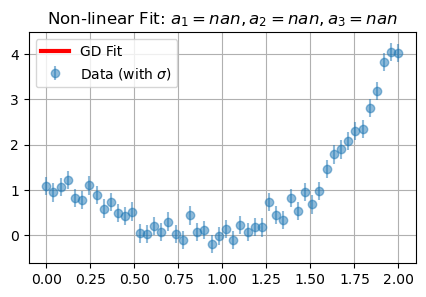

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the model function
def model(x, a1, a2, a3):
    return a1 * x**3 - a2 * x**2 + np.exp(-a3 * x)

# 2. Synthetic Data Generation
np.random.seed(42)
x_data = np.linspace(0, 2, 50)
true_params = [1.5, 2.0, 0.5]
y_true = model(x_data, *true_params)
# Add some noise and define sigma
sigma = 0.2
y_data = y_true + np.random.normal(0, sigma, size=len(x_data))

# 3. Gradient Descent Implementation
def fit_model(x, y, sigma, learning_rate=0.01, iterations=5000):
    # Initial guesses for a1, a2, a3
    a1, a2, a3 = 1.0, 1.0, 1.0 
    
    for i in range(iterations):
        y_pred = model(x, a1, a2, a3)
        error = y - y_pred
        
        # Weighted partial derivatives (the "sensitivity" parts)
        # Formula: sum( (error / sigma^2) * partial_derivative )
        grad_a1 = np.sum((error / sigma**2) * (x**3))
        grad_a2 = np.sum((error / sigma**2) * (-x**2))
        grad_a3 = np.sum((error / sigma**2) * (-x * np.exp(-a3 * x)))
        
        # Update parameters (a_next = a_cur + 2 * gamma * grad)
        a1 += 2 * learning_rate * grad_a1
        a2 += 2 * learning_rate * grad_a2
        a3 += 2 * learning_rate * grad_a3
        
    return a1, a2, a3

# Run the fit
a1_fit, a2_fit, a3_fit = fit_model(x_data, y_data, sigma)

# 4. Visualization
plt.figure(figsize=(5, 3))
# Use a raw string (r"") for the LaTeX portion of the label.
plt.errorbar(x_data, y_data, yerr=sigma, fmt='o', label=r'Data (with $\sigma$)', alpha=0.5)
plt.plot(x_data, model(x_data, a1_fit, a2_fit, a3_fit), color='red', label='GD Fit', lw=3)
plt.title(f"Non-linear Fit: $a_1={a1_fit:.2f}, a_2={a2_fit:.2f}, a_3={a3_fit:.2f}$")
plt.legend()
plt.grid(True)
plt.show()

#### Understanding WLS with example-2
$$\chi^2 = \sum_i \left(y_i - a_1(1 - e^{-a_2 x_i^2})\right)^2$$
* WLS function is $f(x_i; \mathbf{a}) = a_1(1 - e^{-a_2 x_i^2})$
* Two parameter ($a_1, a_2$)
* $\sigma_i^2=1$ given
* To find the Jacobian $J= [\dfrac{\partial (\chi^2)}{\partial a_1}, \dfrac{\partial (\chi^2)}{\partial a_2}]$

1-Calculate the Partial Derivatives: $\frac{\partial y}{\partial a_k}$
* $a_1$: $\dfrac{\partial f}{\partial a_1} = 1 - e^{-a_2 x_i^2}$
* $a_2$: $\dfrac{\partial f}{\partial a_2} = a_1 x_i^2 e^{-a_2 x_i^2}$

2-Put them together
$$
\mathbf{J} =
\begin{bmatrix}
\dfrac{\partial (\chi^2)}{\partial a_1} =-2\sum_i (y_i - a_1(1 - e^{-a_2 x_i^2})) \left(1 - e^{-a_2 x_i^2}\right) \\
\dfrac{\partial (\chi^2)}{\partial a_2} =-2\sum_i (y_i - a_1(1 - e^{-a_2 x_i^2}))\, a_1 x_i^2 e^{-a_2 x_i^2}
\end{bmatrix}
$$


#### Understanding WLS with example-3: Gaussian Peak Funciton
$$y(x; \sigma, xp, I, b) = b + \frac{I}{\sigma \sqrt{2\pi}} e^{-\dfrac{(x-xp)^2}{2\sigma^2}}$$

Use the SymPy code to get the Latex code of Jacobian Derivatives

$$\begin{bmatrix}
    \dfrac{\partial (\chi^2)}{\partial \sigma} = - \frac{\sqrt{2} I \left(\sigma^{2} - \left(x - xp\right)^{2}\right) \left(\sqrt{2} I + 2 \sqrt{\pi} \sigma \left(b - y_{obs}\right) e^{\frac{\left(x - xp\right)^{2}}{2 \sigma^{2}}}\right) e^{- \frac{\left(x - xp\right)^{2}}{\sigma^{2}}}}{2 \pi \sigma^{5}} \\
    \dfrac{\partial (\chi^2)}{\partial xp} = \frac{\sqrt{2} I \left(x - xp\right) \left(\sqrt{2} I + 2 \sqrt{\pi} \sigma \left(b - y_{obs}\right) e^{\frac{\left(x - xp\right)^{2}}{2 \sigma^{2}}}\right) e^{- \frac{\left(x - xp\right)^{2}}{\sigma^{2}}}}{2 \pi \sigma^{4}} \\
    \dfrac{\partial (\chi^2)}{\partial I} = \frac{\sqrt{2} \left(\frac{\sqrt{2} I}{2} + \sqrt{\pi} \sigma \left(b - y_{obs}\right) e^{\frac{\left(x - xp\right)^{2}}{2 \sigma^{2}}}\right) e^{- \frac{\left(x - xp\right)^{2}}{\sigma^{2}}}}{\pi \sigma^{2}} \\
    \dfrac{\partial (\chi^2)}{\partial b} = \frac{\sqrt{2} I e^{- \frac{\left(x - xp\right)^{2}}{2 \sigma^{2}}}}{\sqrt{\pi} \sigma} + 2 b - 2 y_{obs} \\
\end{bmatrix}$$

In [57]:
#Generating the Numerical Jacobian Function
#Generating the Latex

import sympy as sp
import numpy as np

# Define symbols
x, sigma, xp, I, b, y_obs = sp.symbols('x sigma xp I b y_obs', real=True)

# Define Model and Chi-Squared
y_model = b + (I / (sigma * sp.sqrt(2 * sp.pi))) * sp.exp(-(x - xp)**2 / (2 * sigma**2))
chi_sq = (y_model - y_obs)**2

# Calculate Derivatives
params = [sigma, xp, I, b]
J_sym = [sp.diff(chi_sq, p) for p in params]

# Create a fast NumPy function
# The function will take (x, y_obs, sigma, xp, I, b) as inputs
jacobian_func = sp.lambdify((x, y_obs, sigma, xp, I, b), J_sym, 'numpy')

# Example Usage:
# x_data = np.array([1, 2, 3])
# y_data = np.array([0.1, 0.5, 0.1])
# results = jacobian_func(x_data, y_data, sigma=1.0, xp=2.0, I=1.0, b=0.0)


# Mapping for the output
labels = [r"\sigma", r"xp", r"I", r"b"]

print(r"\begin{bmatrix}")
for label, element in zip(labels, J_sym):
    # Simplified the label to be cleaner inside the matrix
    print(f"    \\dfrac{{\\partial (\\chi^2)}}{{\\partial {label}}} = {sp.latex(sp.simplify(element))} \\\\")
print(r"\end{bmatrix}")

\begin{bmatrix}
    \dfrac{\partial (\chi^2)}{\partial \sigma} = - \frac{\sqrt{2} I \left(\sigma^{2} - \left(x - xp\right)^{2}\right) \left(\sqrt{2} I + 2 \sqrt{\pi} \sigma \left(b - y_{obs}\right) e^{\frac{\left(x - xp\right)^{2}}{2 \sigma^{2}}}\right) e^{- \frac{\left(x - xp\right)^{2}}{\sigma^{2}}}}{2 \pi \sigma^{5}} \\
    \dfrac{\partial (\chi^2)}{\partial xp} = \frac{\sqrt{2} I \left(x - xp\right) \left(\sqrt{2} I + 2 \sqrt{\pi} \sigma \left(b - y_{obs}\right) e^{\frac{\left(x - xp\right)^{2}}{2 \sigma^{2}}}\right) e^{- \frac{\left(x - xp\right)^{2}}{\sigma^{2}}}}{2 \pi \sigma^{4}} \\
    \dfrac{\partial (\chi^2)}{\partial I} = \frac{\sqrt{2} \left(\frac{\sqrt{2} I}{2} + \sqrt{\pi} \sigma \left(b - y_{obs}\right) e^{\frac{\left(x - xp\right)^{2}}{2 \sigma^{2}}}\right) e^{- \frac{\left(x - xp\right)^{2}}{\sigma^{2}}}}{\pi \sigma^{2}} \\
    \dfrac{\partial (\chi^2)}{\partial b} = \frac{\sqrt{2} I e^{- \frac{\left(x - xp\right)^{2}}{2 \sigma^{2}}}}{\sqrt{\pi} \sigma} + 2 b - 2 y_{o

#### Understanding WLS with example-4: Fit Gaussian PDF for a given Dataset
1-Plot the histogram of the dataset, and compare with the histogram of our initial Gaussian Estimation
$$f(\mathbf{x};\mu, \sigma) = \frac{1}{\sigma\sqrt{2\pi}}\exp\left(-\frac{(\mathbf{x} - \mu)^2}{2\sigma^2}\right)$$

2-Compare these two histograms, and use $\chi^2$ to represent how well they match
$$\chi^2 = \sum_i (y_i - f(\mathbf{x_i};\mu, \sigma))^2$$

In [60]:
# samples Height Dataset preparison

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

def gaussian(x, mu, sigma):
    return np.exp(-(x-mu)**2/(2*sigma**2)) / (np.sqrt(2*np.pi)*sigma)


def heights_data():
    x = np.arange(50, 300, 2.5)
    width = x[1] - x[0]
    x = x + width/2

    y = np.zeros_like(x)
    idx = (x > 158) & (x < 198)
    data_points = np.array([0.031, 0.013, 0.023, 0.064, 0.065, 0.126, 0.132, 0.127, 0.113, 0.091, 0.105, 0.050, 0.018, 0.018, 0.018, 0.001])
    y[idx] = data_points[:np.sum(idx)]
    y = y / (np.sum(y) * width)

    return x, y

On purpose, we chose mu=155, but not the average of dataset.
This initial Gaussian Estimation is used to show a bad fit.
There is little overlap, and big χ² = 0.0309.


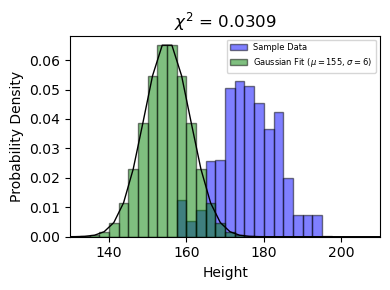

In [62]:
# Get the data, note we only have the grouped data (each bin, and its proportion out of total)
binCentre, hist = heights_data()
width = binCentre[1] - binCentre[0]

# Start with a random guess for the Gaussian PDF parameters, prefer mu as the average of dataset
#mu=(np.min(binCentre) + np.max(binCentre))/2

# use mu=155 just to show a bad fit at beginning
mu = 155
sigma=6

# Plot the sample data histogram
fig, ax = plt.subplots(figsize=(4, 3), dpi=100)
ax.bar(binCentre, hist, width=width, alpha=0.5, color='blue', edgecolor="black", label='Sample Data')

# Plot the initial guess of Gaussian Fit
xs = np.linspace(130, 210, 800)
gaussian_hist = gaussian(binCentre, mu, sigma)
ax.bar(binCentre, gaussian_hist, width=width, alpha=0.5, color='green', edgecolor="black", label = fr'Gaussian Fit ($\mu={mu}$, $\sigma={sigma}$)')

# Add in the Gaussian PDF Curve
ax.plot(binCentre, gaussian_hist, 'k-', linewidth=1)

# Calculate Chi-squared statistic
chi_sq = np.sum((gaussian_hist - hist)**2)

# Final formatting
ax.set_xlim(130, 210)
ax.set_xlabel('Height')
ax.set_ylabel('Probability Density')
ax.set_title(f'$\\chi^2$ = {chi_sq:.4f}')
ax.legend(loc='upper right', fontsize=6)

print('On purpose, we chose mu=155, but not the average of dataset.')
print('This initial Gaussian Estimation is used to show a bad fit.')
print(fr'There is little overlap, and big χ² = {chi_sq:.4f}.')
plt.tight_layout()
plt.show()

3-Use Gradient Decent Approach to find the optimal parameters $(\mu, \sigma)$ that minimize $\chi^2$

From this part $\exp\left(-\dfrac{(\mathbf{x} - \mu)^2}{2\sigma^2}\right)$ in the Gaussian PDF, we know that the parameters $(\mu, \sigma)$ are non-Linear, thus we'll need the iterative gradient descent updates to find their optimal values.
$$\chi^2 = \sum (y_i - f_i)^2$$
$$\nabla \chi^2 = \sum 2(y_i - f_i) \cdot (-\nabla f_i) = -2 \sum (y_i - f_i) \nabla f_i$$

Since Gradient Descent is $a_{next} = a_{cur} - \gamma \nabla \chi^2$, the two negatives cancel out, giving you this Iteration Function
$$a_{next} = a_{cur} + 2\gamma \sum_{i=1}^{n} (y_i - f(x_i; \mu, \sigma)) \frac{\partial f}{\partial a}$$

Note, $\gamma$ is the 'Learning Rate': A small constant that controls how big of a step you take.

Put $(\mu, \sigma)$ into this Iteration funciton, we got
* For $\mu$:
$$\frac{\partial f}{\partial \mu} = f(x; \mu, \sigma) \cdot \frac{(x - \mu)}{\sigma^2}$$
$$\mu_{next} = \mu_{cur} + 2\gamma \sum_{i=1}^{n} \left( y_i - f_i \right) \cdot \left[ f_i \frac{(x_i - \mu)}{\sigma^2} \right]$$
* For $\sigma$:
$$\frac{\partial f}{\partial \sigma} = f(x; \mu, \sigma) \cdot \left[ \frac{(x - \mu)^2}{\sigma^3} - \frac{1}{\sigma} \right]$$
$$\sigma_{next} = \sigma_{cur} + 2\gamma \sum_{i=1}^{n} \left( y_i - f_i \right) \cdot \left[ f_i \left( \frac{(x_i - \mu)^2}{\sigma^3} - \frac{1}{\sigma} \right) \right]$$

4-The Convience of Numpy Array Calculation
$$\sum_{i=1}^{n} (y_i - f(x_i; \mu, \sigma)) \frac{\partial f}{\partial a}$$

Instead of doing the summation for each number $(x_i, y_i)$, the `Dot Product @` of the Numpy Array $(x, y)$ in this step
```python
J = np.array([-2*(y - f(x,mu,sig)) @ dfdmu(x,mu,sig), -2*(y - f(x,mu,sig)) @ dfdsig(x,mu,sig)])
```
handles the summation: $\mathbf{a} \, @ \, \mathbf{b} = \displaystyle \sum_{i=1} a_i b_i$, the `core benefit of Vectorization`.

In [65]:
def f (x,mu,sig) :
    return np.exp(-(x-mu)**2/(2*sig**2)) / np.sqrt(2*np.pi) / sig

def dfdmu (x,mu,sig) :
    return f(x, mu, sig) * (x - mu) / (sig**2)

def dfdsig (x,mu,sig) :
    return f(x, mu, sig) * ((x - mu)**2 / sig**3 - 1/sig)

def steepest_step (x, y, mu, sig, aggression) :
    # calculate the Gradient Ascent
    J = np.array([-2*(y - f(x,mu,sig)) @ dfdmu(x,mu,sig), 
                  -2*(y - f(x,mu,sig)) @ dfdsig(x,mu,sig)])

    # Flip the sign to be Gradient Descent, and multiply by the Learning Rate
    step = -J * aggression
    return step

# Initial guesses
mu, sig, aggression= 155.0, 6.0, 500
path = [[mu, sig]]

# Optimization loop
for i in range(150):
    step = steepest_step(binCentre, hist, mu, sig, aggression)
    mu += step[0]
    sig += step[1]
    path.append([float(mu), float(sig)])

print('Check the last ten pairs to see if the iteration has converged:')
path = np.array(path)
path[-10:]


Check the last ten pairs to see if the iteration has converged:


array([[176.01961172,   7.54990292],
       [176.01963958,   7.54990332],
       [176.01966379,   7.54990372],
       [176.01968483,   7.54990409],
       [176.01970311,   7.54990445],
       [176.019719  ,   7.54990478],
       [176.0197328 ,   7.54990509],
       [176.01974479,   7.54990538],
       [176.01975522,   7.54990563],
       [176.01976427,   7.54990587]])

In [67]:
def contour(path):
    binCentre, hist = heights_data()
    mu_range    = np.arange(150, 200.5, 0.5)
    sigma_range = np.arange(2,   35.5,  0.5)

    error = ((gaussian(binCentre[:, None, None], mu_range[None, :, None], sigma_range[None, None, :]) - hist[:, None, None])**2).sum(axis=0)
    # shape: (len(mu), len(sigma))

    fig, ax = plt.subplots(figsize=(8, 6), dpi=80)
    ax.set_facecolor('lightblue')
    ax.contour(mu_range, sigma_range, error.T, 20, colors=['green'])  # .T fixes the shape
    ax.plot(path[:, 0], path[:, 1], 'o-', color='red', linewidth=1, markersize=1.5)
    ax.set_xlabel("$\\mu$")
    ax.set_ylabel("$\\sigma$")
    plt.show()

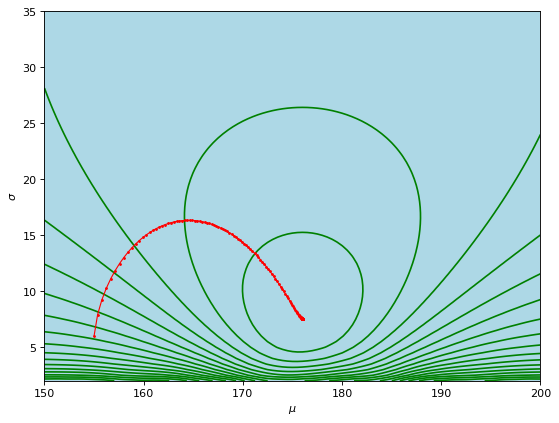

In [68]:
contour(path)

After the Interation Process, we choose mu and sigma at the convergence point
The estimation matches dataset well, with χ² = 0.0004.


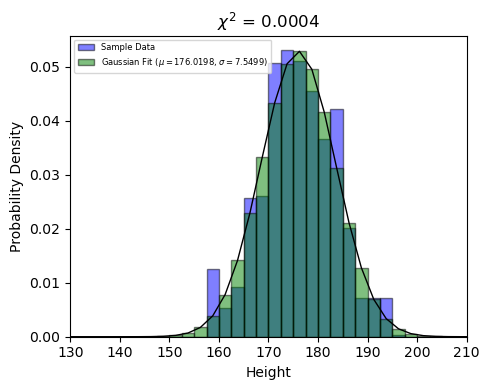

In [70]:
# Get the data, note we only have the grouped data (each bin, and its proportion out of total)
binCentre, hist = heights_data()
width = binCentre[1] - binCentre[0]

# Start with a random guess for the Gaussian PDF parameters, prefer mu as the average of dataset
#mu=(np.min(binCentre) + np.max(binCentre))/2

# use mu=155 just to show a bad fit at beginning
mu = path[-1][0]
sigma= path[-1][1]

# Plot the sample data histogram
fig, ax = plt.subplots(figsize=(5, 4), dpi=100)
ax.bar(binCentre, hist, width=width, alpha=0.5, color='blue', edgecolor="black", label='Sample Data')

# Plot the initial guess of Gaussian Fit
xs = np.linspace(130, 210, 800)
gaussian_hist = gaussian(binCentre, mu, sigma)
ax.bar(binCentre, gaussian_hist, width=width, alpha=0.5, color='green', edgecolor="black", label = fr'Gaussian Fit ($\mu={mu:.4f}$, $\sigma={sigma:.4f}$)')

# Add in the Gaussian PDF Curve
ax.plot(binCentre, gaussian_hist, 'k-', linewidth=1)

# Calculate Chi-squared statistic
chi_sq = np.sum((gaussian_hist - hist)**2)

# Final formatting
ax.set_xlim(130, 210)
ax.set_xlabel('Height')
ax.set_ylabel('Probability Density')
ax.set_title(f'$\\chi^2$ = {chi_sq:.4f}')
ax.legend(loc='upper left', fontsize=6)

print('After the Interation Process, we choose mu and sigma at the convergence point')
print(fr'The estimation matches dataset well, with χ² = {chi_sq:.4f}.')
plt.tight_layout()
plt.show()

### Mar-17-2026

#### Calculate Mean, Covariance after Affine (latin: related) Transformation
* We use Expected Values to represent Mean in this course. $\mathrm E(X) = \dfrac{1}{N} \displaystyle \sum_i^N x_i$
* Covariance: $\mathrm {Cov}(X, Y) = \dfrac{1}{N} \displaystyle \sum_i^N (x_i - \bar x)(y_i - \bar y)^T$
* After an affine transformation: $X' = A \cdot X + \vec b$
  * the new Mean: $\mathrm E(X') = A \cdot \mathrm E(X) + \vec b$
  * the new Covariance: $\mathrm{Cov}(X', Y') = A \cdot \mathrm{Cov}(X, Y) \cdot B^T$

#### Numpy Vectorization
* The Concept: Shifting from element-wise loops (explicit `for` loops in Python) to operations on the entire array (vector) at once.
* Fundamental Building Blocks:
    * NumPy Array: The `ndarray` is the primary object.
        * `X = np.array([[1, 2, 3], [4, 5, 6]])`
        * `X.shape = (N, D)`
    * Arithmetic Operators: These are applied element-wise by default.
        * `+`, `-`, `*`, `/`, `**`, `@`
    * Universal Functions (ufuncs): These are functions that operate on the `ndarray` in an element-by-element fashion.
        * `np.sqrt(X)`, `np.exp(X)`, `np.log(X)`, `np.inner(X)`
        * `np.sum(X)`, `np.sum(X, axis=0)`, `np.mean(X, axis=1, keepdims=True)`
    * Mean and Covariance Calculation
      * `X_centered = X - np.mean(X, axis=0)`
      * `cov = (X_centered.T @ X_centered) / N`

#### Affine Transformations: Linear vs Affine
* Affine Transformation = Linear Transformation + Translation
* Linear transformations (like rotation or scaling) must keep the origin $(0, 0)$ fixed. 
* Affine transformations allow the origin to move, the $\vec b$ part.
* Mathematically, it is often represented by the formula: $X' = A \cdot X + \vec b$,
  * $A \cdot X$ represents the linear part (the "shape" change),
  * $\vec b$ represents the translation vector (the "sliding" part).

### Mar-18-2026

#### Generalized Inner Product, inner product on $M$: 
$$\langle \mathbf{u}, \mathbf{v} \rangle_M = \mathbf{u}^T M \mathbf{v}$$
Requiring: 
* Symmetric: $\langle \mathbf{u}, \mathbf{v} \rangle_M = \langle \mathbf{v}, \mathbf{u} \rangle_M$
* Postive Definite: $\langle \mathbf{u}, \mathbf{u} \rangle_M \gt 0$, and $\langle \mathbf{0}, \mathbf{0} \rangle_M = 0$
* Bilinear: $\langle \mathbf{\lambda v + u}, \mathbf{z} \rangle_M = \lambda \langle \mathbf{v}, \mathbf{z} \rangle_M + \langle \mathbf{u}, \mathbf{z} \rangle_M$

#### The Dot Product
* If we set $M = I$ (the Identity matrix), the generalized formula becomes:
$$\langle \mathbf{u}, \mathbf{v} \rangle_I = \mathbf{u}^\top I \mathbf{v} = \mathbf{u}^\top \mathbf{v}$$



In [71]:
import numpy as np

def inner_product(u, v, M):
    # Calculate u.T @ M @ v
    return u.T @ M @ v

def test_inner_product_properties(M, dim=3):
    # 1. Check Symmetry of the Matrix M itself
    is_symmetric_matrix = np.allclose(M, M.T)
    
    # 2. Check Positive Definiteness (All eigenvalues > 0)
    eigenvalues = np.linalg.eigvals(M)
    is_positive_definite = np.all(eigenvalues > 0)
    
    # Generate random vectors for functional tests
    u = np.random.rand(dim)
    v = np.random.rand(dim)
    z = np.random.rand(dim)
    lmbda = np.random.randn()

    # 3. Test Symmetry: <u, v> == <v, u>
    val_uv = inner_product(u, v, M)
    val_vu = inner_product(v, u, M)
    is_symmetric_func = np.isclose(val_uv, val_vu)

    # 4. Test Bilinearity (First slot): <lambda*v + u, z> == lambda*<v, z> + <u, z>
    lhs = inner_product(lmbda * v + u, z, M)
    rhs = lmbda * inner_product(v, z, M) + inner_product(u, z, M)
    is_bilinear = np.isclose(lhs, rhs)

    # 5. Test Positive Definiteness (Functional): <u, u> > 0 for non-zero u
    is_pos_func = inner_product(u, u, M) > 0

    print(f"Matrix Symmetry: {is_symmetric_matrix}")
    print(f"All Eigenvalues > 0: {is_positive_definite} (Values: {eigenvalues})")
    print(f"Functional Symmetry: {is_symmetric_func}")
    print(f"Bilinearity Check: {is_bilinear}")
    print(f"Positive Definite Check: {is_pos_func}")

# --- Example Usage ---
# Identity Matrix (The Dot Product)
I = np.eye(3)
print("Testing Identity Matrix:")
test_inner_product_properties(I)

# A non-positive definite matrix (Should fail)
M_fail = np.array([[1, 2], [2, 1]])
print("\nTesting Non-Positive Definite Matrix:")
test_inner_product_properties(M_fail, dim=2)

Testing Identity Matrix:
Matrix Symmetry: True
All Eigenvalues > 0: True (Values: [1. 1. 1.])
Functional Symmetry: True
Bilinearity Check: True
Positive Definite Check: True

Testing Non-Positive Definite Matrix:
Matrix Symmetry: True
All Eigenvalues > 0: False (Values: [ 3. -1.])
Functional Symmetry: True
Bilinearity Check: True
Positive Definite Check: True


#### Inner Product: angles
$$\cos(\theta) = \frac{\langle \mathbf{u}, \mathbf{v} \rangle_M}{\|\mathbf{u}\|_M \|\mathbf{v}\|_M}$$

To solve for the angle $\theta$:

$$\theta = \arccos\left( \frac{\mathbf{u}^\top M \mathbf{v}}{\sqrt{\mathbf{u}^\top M \mathbf{u}} \sqrt{\mathbf{v}^\top M \mathbf{v}}} \right)$$

Orthogonality
* Two vectors are considered orthogonal (perpendicular) in this space $M$
* if and only if: $\mathbf{u}^\top M \mathbf{v} = 0$


In [72]:
import numpy as np
# the matrix A defines the inner product
A = np.array([[2, 1],[1,4]])
x = np.array([2,2])
y = np.array([-2,-2])

def angle_between(u, v, M):
    dot_product = u.T @ M @ v
    norm_u = np.sqrt(u.T @ M @ u)
    norm_v = np.sqrt(v.T @ M @ v)
    
    # Clip to handle potential floating point errors outside [-1, 1]
    cos_theta = np.clip(dot_product / (norm_u * norm_v), -1.0, 1.0)
    return np.arccos(cos_theta) # Returns angle in radians

angle_between(x, y, A), np.degrees(angle_between(x, y, A))

(np.float64(3.1415926325163688), np.float64(179.99999879258172))

### Mar-19-2026

#### Understanding the Handwritten Digit Dataset (MNIST)
* Loaded via: `from tensorflow.keras.datasets import mnist`
* The MNIST dataset contains 70,000 grayscale images (60,000 training and 10,000 test), each labeled with a digit from 0–9
* This demo selects 10 samples per digit, for a total of 100 images
* Each 28×28 pixel image is flattened into a 784-dimensional vector
* The images can then be clustered using K-Means, where each image is treated as a point in ℝ⁷⁸⁴ and assigned to the nearest centroid based on Euclidean distance.


1-Let's take a look at all the images of `0` first.

```python
# need this dataset mnist_digit_0.csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

image_0 = pd.read_csv('mnist_digit_0.csv').to_numpy()
image_0 = image_0.reshape(-1, 28, 28)

# Assuming your array is named 'digit_images' with shape (10, 28, 28)
fig, axes = plt.subplots(2, 5, figsize=(6, 3))

# Flatten the axes array to easily iterate over it
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(image_0[i], cmap='gray')
    axes[i].axis('off')  # Hide the pixel scales for a cleaner look

plt.tight_layout()
plt.show()
```

2-Load images for all digits into one dataframe, and label them out.

```python
dfs = []

for digit in range(10):
    df = pd.read_csv(f'mnist_digit_{digit}.csv')
    df['label'] = digit
    dfs.append(df)

images_df = pd.concat(dfs, ignore_index=True)

images_df.iloc[[3, 13, 23, 33], :]
```

3-Use K-Means to cluster the images, based the distance to 10 random centroids.

```python
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Seperate the image vector and their labels
X = images_df.drop(columns=['label']).values   # shape: (N, 784)
y = images_df['label'].values                 # ground truth (not used by K-Means)

# Normalize the image vectors X
X = X / 255.0

# Initiate PCA, reduce the image vector from R784 to R50
pca = PCA(n_components=50)
X_reduced = pca.fit_transform(X)

# Initiate the kmeans, then fit the PCA treated X vectors
kmeans = KMeans(n_clusters=10, n_init=10, random_state=42)
kmeans.fit(X_reduced)

# cluster assignment for each image
clusters = kmeans.labels_   
centroids = kmeans.cluster_centers_

# add back the cluster result to images_df
images_df = images_df.copy()
cluster_map = {i: chr(ord('a') + i) for i in range(10)}
images_df['cluster'] = pd.Series(clusters).map(cluster_map)

images_df.iloc[[3, 13, 23, 33], :]
```

4-Pick a cluster (d), and see if they all show the same digit.

```python
import matplotlib.pyplot as plt
import pandas as pd

# 1. Identify pixel columns
pixel_cols = [c for c in images_df.columns if c not in ['label', 'cluster']]

# 2. Pre-cast to float to avoid the "object" dtype error during imshow
# This is the critical fix for your error!
pixel_data_numeric = images_df[pixel_cols].astype(float)

# 3. Select subsets (using the indices to pull from the numeric data later)
top_samples = images_df[images_df['label'] == 0].iloc[:10]
bottom_samples = images_df[images_df['cluster'] == 'd'].iloc[:10]

fig, axes = plt.subplots(2, 10, figsize=(15, 4))

# --- Top row: label == 0 ---
for i in range(10):
    ax = axes[0, i]
    if i < len(top_samples):
        # Pull from the pre-casted numeric dataframe using the sample's index
        idx = top_samples.index[i]
        img = pixel_data_numeric.loc[idx].values.reshape(28, 28)
        ax.imshow(img, cmap='gray')
    ax.axis('off')

# --- Bottom row: cluster == 'd' ---
for i in range(10):
    ax = axes[1, i]
    if i < len(bottom_samples):
        idx = bottom_samples.index[i]
        img = pixel_data_numeric.loc[idx].values.reshape(28, 28)
        ax.imshow(img, cmap='gray')
    ax.axis('off')

# Adding Row Labels for clarity
axes[0, 0].set_title("Label: 0", loc='left', fontsize=12)
axes[1, 0].set_title("Cluster: d", loc='left', fontsize=12)

plt.tight_layout()
plt.show()
```

### Mar-20-2026

#### Code to Illustrate Orthogonal Projection (1D)

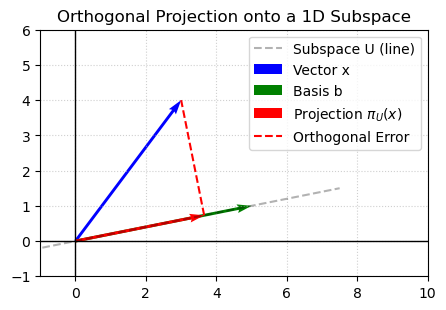

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# Define the vectors
x = np.array([3, 4])        # The vector to be projected
b = np.array([5, 1])        # The basis vector for subspace U

# Calculate the projection scale (lambda)
# lambda = (b.T @ x) / (b.T @ b)
lmbda = np.dot(b, x) / np.dot(b, b)

# Calculate the projection vector pi_U(x)
proj_x = lmbda * b

# Setup the plot
plt.figure(figsize=(5, 5))
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)

# Plot the line representing subspace U
line_scale = 1.5
plt.plot([-line_scale*b[0], line_scale*b[0]], [-line_scale*b[1], line_scale*b[1]], 
         'k--', alpha=0.3, label='Subspace U (line)')

# Plot original vector x
plt.quiver(0, 0, x[0], x[1], angles='xy', scale_units='xy', scale=1, color='blue', label='Vector x')

# Plot basis vector b
plt.quiver(0, 0, b[0], b[1], angles='xy', scale_units='xy', scale=1, color='green', label='Basis b')

# Plot the projection pi_U(x)
plt.quiver(0, 0, proj_x[0], proj_x[1], angles='xy', scale_units='xy', scale=1, color='red', label=r'Projection $\pi_U(x)$')

# Plot the orthogonal error vector (dashed line from proj_x to x)
plt.plot([proj_x[0], x[0]], [proj_x[1], x[1]], 'r--', label='Orthogonal Error')

# Formatting
plt.xlim(-1, 10)
plt.ylim(-1, 6)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.title('Orthogonal Projection onto a 1D Subspace')
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

#### Orthogonal Projection onto a 1D subspace (a line)
* The Line (Subspace $U$): Represented by the dashed gray line passing through the origin.
  * standard definition of a subspace requires that it must pass through the origin.
  * If a line does not pass through the origin, it is technically called an affine subspace.
* The basis vector $\mathbf{b}$, `b = np.array([5, 1])`
  * its norm doesn't have to be 1, just need to be on the Subspace $U$.
* The Projection ($\pi_U(\mathbf{x})$): This is the vector in the direction of $\mathbf{b}$ that is "closest" to $\mathbf{x}$.
  * Defined as: $\pi_U(\mathbf{x}) = \lambda \mathbf{b} = \dfrac{\mathbf{b}^\top \mathbf{x}}{\|\mathbf{b}\|^2} \mathbf{b}$
  * The Projection Matrix $P = \dfrac{\mathbf{b}\mathbf{b}^\top}{\mathbf{b}^\top \mathbf{b}} = \dfrac{\mathbf{b}\mathbf{b}^\top}{\|\mathbf{b}\|^2}$, such that $\pi_U(\mathbf{x}) = P \mathbf{x}$
* Orthogonality: The dashed red line represents the reconstruction error vector $(\mathbf{x} - \pi_U(\mathbf{x}))$.
  * perpendicular to the subspace $U$.

#### Orthogonal Projection onto k-dimensional subspaces
* The k-dimensional subspaces $U$, is defined by its basis matrix $B= \begin{bmatrix} b_1 \\ b_2 \\ \vdots \\ b_k \end{bmatrix}$, formed by basis vectors $b_i$.
* The orthogonal projection of $x$ on $U$ is defined as $\pi_U(\mathbf{x}) = B\lambda, \quad \lambda = (B^\top B)^{-1} B^\top \mathbf{x}$
* The projection matrix $P$: $P = B(B^\top B)^{-1} B^\top$, such that $\pi_U(\mathbf{x}) = P \mathbf{x}$

In [74]:
import sympy as sp
# Given a vector x
x = sp.Matrix([12, 0, 0])

# Define the basis vectors that form the k-dimentional space U
b1 = sp.Matrix([1, 1, 1])
b2 = sp.Matrix([0, 1, 2])

# Build basis matrix B
B = sp.Matrix.hstack(b1, b2)

# Projection matrix
P = B * (B.T * B).inv() * B.T

# and, the results
print(f'The projection matrix P is {P}')
print(f'The projection of x on U is {P * x}')


The projection matrix P is Matrix([[5/6, 1/3, -1/6], [1/3, 1/3, 1/3], [-1/6, 1/3, 5/6]])
The projection of x on U is Matrix([[10], [4], [-2]])


### Apr-08-2026

#### Understanding the Geometric Intuition behind PCA
* Covariance Matrix's Eigenspace
  * Reducing the original dataset, but keeping its variance
* The Projection Math
  * To project $X$ (100, 50) onto a new space, you multiply it by a projection matrix $P$ (50, $k$): $X_{projected} = X \cdot P$
  * $X$: $(100 \times 50)$
  * $P$: $(50 \times k)$: how many eigenvectors you choose.
  * Result: $(100 \times k)$


1-Generate some 3D data, (100, 3) np array $\in N(0, 1)$
* Manully add the correlation to row_1, and row_2 from row_0.
* Always standardize the dataset before PCA

In [40]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# good habit to set up the random generator
rng = np.random.default_rng(seed=42)

# generate a (100, 3) np array
N = 100
X = rng.standard_normal((N, 3))

# adding the Correlation to row1 and row2
X[:, 1] = 2 * X[:, 0] + 0.5 * rng.standard_normal((N, ))
X[:, 2] = -X[:, 0] + 0.2 * rng.standard_normal((N, ))

# standardize the dataset for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

2-Calculate the Covariance Matrix
* Review the basics, the Sample Covariance ($s_{xy}$) for $x$ and $y$ is calculated as:
$$s_{xy} = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{n - 1}$$ 
* For a matrix $X$ with shape (n, m), standardize the dataset first, and the covariance matrix is
$$\text{Cov}(X) = \frac{1}{n - 1} X^T X$$ 


In [41]:
cov = (X_scaled.T @ X_scaled) / (N - 1)

3-The eigenspace of the Covariance Matrix
>review: An $n \times n$ matrix has at most $n$ distinct eigenvalues and at most $n$ linearly independent eigenvectors, though it may have infinitely many eigenvectors in total.

>A set of vectors is linearly independent if none of them can be written as a combination of the others.

* The Eigenspace: The eigenvectors of the (3,3) covariance matrix define a new, orthogonal coordinate system.
  * 1st Eigenvector (with max eigenvalue), deemed as Length. Showing the absolute "longest" direction of the data cloud `X_scaled`, the absolute Max Variance.
  * 2nd Eigenvector, deemed as Width.  Orthogonal (90°) to the 1st eigenvector. Showing the "widest" remaining direction. This is the Second Max Variance for the data cloud `X_scaled`.
  * 3rd Eigenvector, deemed as Thinness. Orthogonal (perpendicular) to the plane formed the first two eigenvectors. This usually represents the "thinness" or the noise of the data cloud (Minimum Variance).
* Selecting the Plane: Choosing the top two eigenvectors (those with the largest corresponding eigenvalues)
  * we now have the two directions along which the data has the most "spread" or variance.
  * These two vectors indeed define a 2D plane (a subspace) within the 3D space.
* Projection: Projecting the original 3D points onto this specific plane effectively collapses the 3D data into 2D.
* Principal Components: The resulting 2D coordinates are the first two Principal Components (PCs) of the dataset `X_scaled`.
  * This process preserves as much information (variance) as possible while reducing the dimensions from 3 to 2.

In [42]:
# use numpy's linear algebra to get the eignvalues, and eigenvectors for the covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov)

# sort them by the value of eigenvalues, desc.
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]


note, in the `np.linalg.eig(cov)` function, the eigenvectors are stored in columns, so `eigenvectors[:, 0]` is one actual eigenvector. 
```python
v1 = eigenvectors[:, 0]
v2 = eigenvectors[:, 1]
v3 = eigenvectors[:, 2]
```

4-In PCA, the data is projected onto an orthonormal basis of eigenvectors of the covariance matrix.
* In this new coordinate system:
  * the projected variables are uncorrelated, as each axis is orthogonal to another
  * each axis is a principal direction
  * the first eigenvector gives the direction along which the data has maximum variance
  * the second eigenvector gives the largest remaining variance subject to being orthogonal to the first
  * and so on

In [47]:
# Take the first two eigenvector, and form a plane
W = eigenvectors[:, :2]

# projected the dataset (100 x 3) to this plane, now (100 x 2)
Z = X_scaled @ W

# now we are with the first two principal components of the original dataset
X_scaled.shape, W.shape, Z.shape

((100, 3), (3, 2), (100, 2))

5-Plot them out

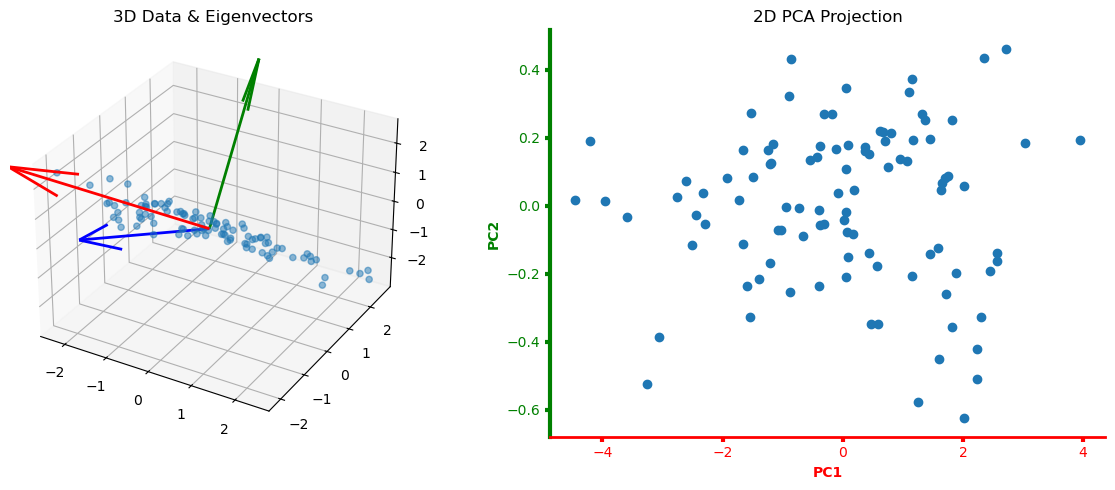

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# set up the 3D space
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(121, projection='3d')

# plot the original datapoint cloud X_scaled
ax.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2], alpha=0.5)

# plot the eigenspace of the cov matrix
ox, oy, oz = [0, 0, 0]
ax.quiver(ox, oy, oz, *v1, length=5, color='red', linewidth=2, label='PC1')
ax.quiver(ox, oy, oz, *v2, length=5, color='green', linewidth=2, label='PC2')
ax.quiver(ox, oy, oz, *v3, length=5, color='blue', linewidth=2, label='PC3')
ax.set_title("3D Data & Eigenvectors")

# set up the 2D PCA plane
ax2 = fig.add_subplot(122)
ax2.set_title("2D PCA Projection")

# mark out the first eigenvector
ax2.set_xlabel("PC1", color='red', fontweight='bold')
ax2.spines['bottom'].set_color('red')
ax2.spines['bottom'].set_linewidth(2)
ax2.tick_params(axis='x', colors='red', width=3)

# mark out the second eigenvector
ax2.set_ylabel("PC2", color='green', fontweight='bold')
ax2.spines['left'].set_color('green')
ax2.spines['left'].set_linewidth(3)
ax2.tick_params(axis='y', colors='green', width=3)

# clean up the top and right borders, just to illustrate the first two eigenvectors
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


# plot the projected Z
ax2.scatter(Z[:, 0], Z[:, 1])

plt.tight_layout()
plt.show()


### Apr-09-2026

#### Understanding PCA with Singular Value Decomposition (SVD)
* 

1- we start with a data matrix `X50_raw` of size (100, 50) (100 samples, 50 features) and want to reduce it to (100, 10)
*  Using `StandardScaler` ensures every one of those 50 features has a mean of 0 (centered) and a standard deviation of 1 (standardized).

In [1]:
import numpy as np

# setup the random generator
rng = np.random.default_rng(seed=42)

# generate two matrix, (100, 10) and (10, 50)
latent_factors = rng.standard_normal((100, 10)) 
mixing_matrix = rng.standard_normal((10, 50))

# their dot prodcut will create the correlation
X50_raw = latent_factors @ mixing_matrix

# add a bit of random noise
X50_raw += rng.standard_normal((100, 50)) * 0.1


# Always standardize the dataset before PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X50_scaled = scaler.fit_transform(X50_raw)

X50_scaled.shape

(100, 50)

2-Singular Value Decomposition (SVD): $X_{\text{scaled}} = U \Sigma \cdot V^T$
* For $X \in \mathbb{R}^{m \times n}$, where, m is the number of rows/samples/observations, and n is number of columns/features/variables
* `X_scaled = StandardScaler().fit_transform(X)` centers each feature to mean $0$ and scales each feature to standard deviation $1$.
* $U$ is an (m, m) orthogonal matrix, its columns are eigenvectors of $X_{\text{scaled}}X_{\text{scaled}}^T$
* $\Sigma$ contains the singular values, sorted from largest to smallest.
* $V$ is an (n, n) orthogonal matrix,its columns are eigenvectors of $X_{\text{scaled}}^TX_{\text{scaled}}$

With this (100, 50) `X50_scaled`
| Matrix| Name | Dimensions | Represents |
|---|---|---|---|
| $X_{\text{scaled}}$ | Data | $100 \times 50$ | Original Data |
| $U$ | Left Singular | $100 \times 100$ | Sample Relationships |
| $\Sigma$ | Singular Values | $100 \times 50$ | Importance/Energy |
| $V^T$ | Right Singular | $50 \times 50$ | Feature Relationships |

Put SVD back to our good old PCA projection interpretation
$$
X_{\text{scaled}} V = U \Sigma
$$
* projection onto the eigenvector basis of the covariance matrix
* both $U\,, V$ are orthogonal: $A^T A = A A^T = I$
* columns of $V$ are eigenvectors of the  covariance matrix: Cov(X_scaled).


3-full SVD, reduced SVD, and Dimensionality Reduction (The Compression)
$$
X_{\text{scaled}} V_{10} = U_{10} \Sigma_{10}
$$
In most real-world data, 50 features are redundant. SVD allows you to perform Dimensionality Reduction.
* If you look at $\Sigma$ and see that only the first 10 singular values are large, you can throw away the other 40.
* To reduce your 50 columns down to 10, we simply "truncate" the matrices.
  * keep only the first 10 columns of $U$
  * the top-left $10 \times 10$ block of $\Sigma$
  * and the first 10 columns of $V$.

Alternatively, the most common way to express the projection is:
* Take the first 10 Principal Components (the first 10 columns of $V$), let's call this $V_{10}$ with (50, 10).
* Project the original data onto these components:
$$X_{reduced} = X_{\text{scaled}} V_{10} = U_{10} \Sigma_{10}$$
* Resulting Matrix $X_{reduced}$: (100, 10)

In [10]:
# Perform SVD
U, S, Vt = np.linalg.svd(X50_scaled, full_matrices=False)

# Take the first 10 Principal Components
V10 = Vt[:10, :].T 

# Project the data into the new 10D space
# Matrix multiplication: (100, 50) @ (50, 10) = (100, 10)
X10_reduced = np.dot(X50_scaled, V10)

# do this wit scikit-learn
from sklearn.decomposition import PCA
pca_10 = PCA(n_components=10, random_state=42)
X10_reduced_sklearn = pca_10.fit_transform(X50_scaled)

# check if the results are close
np.allclose(np.abs(X10_reduced), np.abs(X10_reduced_sklearn))

True

4-understanding the code
* `full_matrices=False`: This performs "Reduced SVD." Since `X50_scaled` is (100, 50), the full $U$ matrix would be (100, 100). By setting this to `False`, NumPy returns $U$ as (100, 50), which saves memory and matches our feature count.
* The Projection: Notice that `X_reduced` is just the dot product of  `X50_scaled` and `Vt[:10, :].T`.
* Singular Values ($S$): NumPy returns $S$ as a 1D array of length 50. To see how much "information" you kept, you square these values (to get the eigenvalues) and look at their ratio against the sum of all squared singular values.


### Apr-14-2026

#### Improving Signal-to-Noise Ratio in Raman Spectra
* Denoising Strategies from PCA to Deep Learning (with TF2 Funcitonal API)

1-We'll start with the physical reality of Raman scattering. 
* When a photon of energy $\hbar \omega$ hits a molecule, it provides enough energy to 'excite' the system. If this energy matches the gap between two stable electronic levels (like jumping from the ground state $S_0$ to an excited state $S_1$), the photon is absorbed.
* However, in Raman scattering, the incoming photon usually does not have exact energy to reach a stable, real excited electronic state. Instead, we imagine the molecule reaching a virtual state: an unstable, short-lived energy level that exists only during the interaction with the electromagnetic field of the photon.
* In other words, Raman Scattering occurs when the photon does not match an exact electronic transition, forcing the system into a momentary, polarized "virtual" state before it immediately re-emits a photon.
* The virtual state represents the distortion of the molecule's electron cloud (polarization) by the oscillating electric field of the incident light.
* The scattering process can be visualized in three distinct outcomes based on the transition through this virtual state. 
| Type of Scattering | Process Description | Result |
| :--- | :--- | :--- |
| **Rayleigh** | The molecule reaches the virtual state and returns to the **same** initial vibrational level. | No change in energy/color. |
| **Stokes Raman** | The molecule reaches the virtual state and drops back to a **higher** vibrational level. | Emitted photon has less energy (red-shifted). |
| **Anti-Stokes Raman** | The molecule starts in a vibrationally excited state, reaches the virtual state, and drops to the **ground** level. | Emitted photon has more energy (blue-shifted). |
* Below is the plot of all Three Types of Raman Scattering from Sudan Red C=C, N=N Stretching.

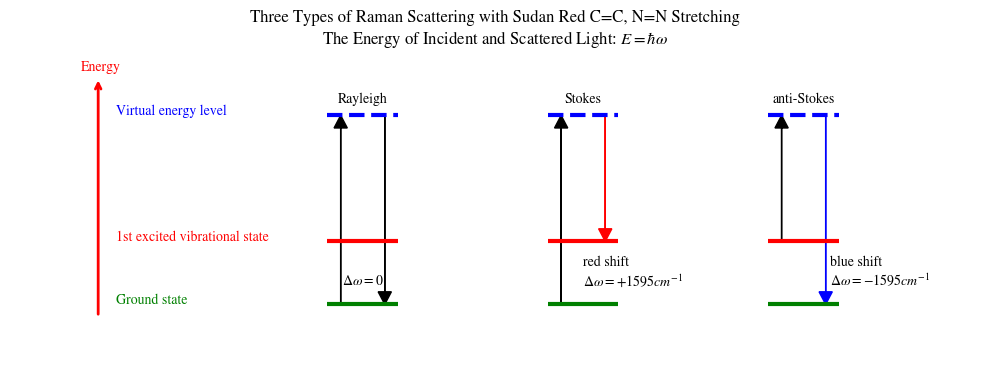

In [1]:
import matplotlib.pyplot as plt

# configure Matplotlib to use the STIX font family for mathematical text and general text in plots
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

fig, ax = plt.subplots(figsize=(10, 4))

# X Positions of all three scattering types
x_rayleigh, x_stokes, x_antistokes = 4, 6.5, 9

# Y Positions of three Energy levels
E0, E1, Ev = 0, 1, 3

# a function to draw three horizontal lines, representing the three energy levels
def levels(x):
    ax.hlines(E0, x-0.4, x+0.4, linewidth=3, color='green')
    ax.hlines(E1, x-0.4, x+0.4, linewidth=3, color='red')
    ax.hlines(Ev, x-0.4, x+0.4, linewidth=3, color='blue', linestyle='--')

# draw all three horizontal lines for each scattering type
for x in [x_rayleigh, x_stokes, x_antistokes]:
    levels(x)

# draw an upward arrow to show Energy goes up from group to virtual state
ax.annotate('', xy=(1, 3.6), xytext=(1, -0.2), arrowprops=dict(arrowstyle='->', color='red', linewidth=2))
ax.text(0.8, 3.7, 'Energy', color='red', fontsize=10)

# label each energy state
ax.text(1.2, Ev, 'Virtual energy level', color='blue', fontsize=10)
ax.text(1.2, E1, r'1st excited vibrational state', color='red', fontsize=10)
ax.text(1.2, E0, 'Ground state', color='green', fontsize=10)

# For Rayleigh Scattering
# draw vertical arrows to show the incident light
ax.arrow(x_rayleigh-0.25, E0, 0, Ev-E0, length_includes_head=True, 
         head_width=0.15, head_length=0.2, fc='black', ec='black')

# draw vertical arrows to show the scattered light
ax.arrow(x_rayleigh+0.25, Ev, 0, -(Ev-E0), length_includes_head=True, 
         head_width=0.15, head_length=0.2, fc='black', ec='black')

ax.annotate('Rayleigh', xy=(x_rayleigh, Ev+0.2), ha='center')
ax.annotate(r'$\Delta \omega = 0$', xy=(x_rayleigh, E0+0.3), ha='center')

# For Stokes Scattering
# draw vertical arrows to show the incident light
ax.arrow(x_stokes-0.25, E0, 0, Ev-E0, length_includes_head=True, 
         head_width=0.15, head_length=0.2, fc='black', ec='black')

# draw vertical arrows to show the scattered light
ax.arrow(x_stokes+0.25, Ev, 0, -(Ev-E1), length_includes_head=True, 
         head_width=0.15, head_length=0.2, fc='red', ec='red')

ax.annotate('Stokes', xy=(x_stokes, Ev+0.2), ha='center')
ax.annotate(r'red shift' '\n' r'$\Delta \omega = + 1595cm^{-1}$', xy=(x_stokes, E0+0.3), ha='left')

# For anti-Stokes Scattering
# draw vertical arrows to show the incident light
ax.arrow(x_antistokes-0.25, E1, 0, Ev-E1, length_includes_head=True, head_width=0.15, 
         head_length=0.2, fc='black', ec='black')

# draw vertical arrows to show the scattered light
ax.arrow(x_antistokes+0.25, Ev, 0, -(Ev-E0), length_includes_head=True, head_width=0.15, 
         head_length=0.2, fc='blue', ec='blue')

ax.annotate('anti-Stokes', xy=(x_antistokes, Ev+0.2), ha='center')
ax.annotate(r'blue shift' '\n' r'$\Delta \omega = - 1595cm^{-1}$', xy=(x_antistokes+0.3, E0+0.3), ha='left')



# Layout
ax.set_xlim(0, 11)
ax.set_ylim(-1.2, 4)
ax.axis('off')
ax.set_title('Three Types of Raman Scattering with Sudan Red C=C, N=N Stretching' 
             '\n'
             r'The Energy of Incident and Scattered Light: $E = \hbar \omega$')

plt.tight_layout()
plt.show()

2-Stokes Raman Scattering and Lorentzian Distribution
* We'll focuse on the Stokes Scattering, as it's much more common compared to the anti-Stokes. Molecues turn to stay at their ground state, and those at the 1st excited state are very rare, roughly $0.05\%$.
* In an ideal world, with infinite-lifetime system, we would expect to see a single line at the Raman Shift of $\Delta \omega = +1595cm^{-1}$ from a Raman spectrum.
* But real world data always show a bell-shaped curve. This curve looks Gaussian, but it's actually __Lorentzian Distribution__, governed by lifetime broadening.
$$L(x) = \frac{1}{\pi} \left[ \frac{\gamma}{(x - x_0)^2 + \gamma^2} \right]$$
* A better way to represent a Raman Shift peak
$$I(\omega) = I_{max} \frac{\gamma^2}{(\omega - \omega_0)^2 + \gamma^2}$$
* $\omega_0$: The peak center $\Delta \omega = +1595cm^{-1}$.
* $I(\omega)$: The intensity at a given Raman Shift.
* $\gamma$: The Half-Width at Half-Maximum (HWHM). This represents the "spectral broadening" caused by the finite lifetime of the virtual state and vibrational state. 


3-Lorentzian is not enough, because more realism, synthetic Raman data often includes
* Pseudo-Voigt profile
  * mixed Gaussian/Lorentzian shapes
  * Gaussian: due to instrument broadening or disorder
* fluorescence baseline
* cosmic spikes
* detector noise
* peak asymmetry
* calibration drift
* below is a synthetic, ideal Reference Raman Spectrum, based on Sudan Red (IV).
  * only three peaks are simulated: $\Delta \omega$: 628, 1095, and 1595 $cm^{-1}$
  * the entire range of Raman Shift will be [400, 1800], with 1400 wavenumbers.
  * 

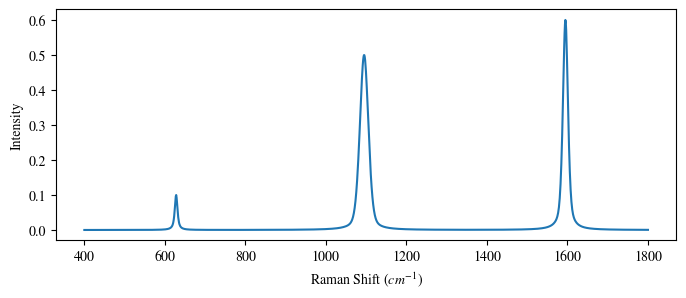

(1400,)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# set up the total range of Raman Shift, and create a blank spectrum
wavenumbers = np.linspace(400, 1800, 1400)
ref_spectrum = np.zeros_like(wavenumbers)

# set up the positioin of three simulated peaks, 
# and their heigh, half-width,and coefficient for Pseudo-Voigt mixture
peak_configs = [{'pos': 628,  'amp': 0.1, 'fwhm': 8,  'shape': 0.8},
                {'pos': 1095, 'amp': 0.5, 'fwhm': 25, 'shape': 0.3},
                {'pos': 1595, 'amp': 0.6, 'fwhm': 15, 'shape': 0.5}
               ]

for p in peak_configs:
    pos, amp, fwhm, eta = p['pos'], p['amp'], p['fwhm'], p['shape']
    
    # Lorentzian component (using 'wavenumbers' instead of 'x')
    lorentz = (fwhm**2 / 4) / ((wavenumbers - pos)**2 + (fwhm**2 / 4))
    
    # Gaussian component
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    gauss = np.exp(-0.5 * ((wavenumbers - pos) / sigma)**2)
    
    # Pseudo-Voigt mixture
    ref_spectrum += amp * (eta * lorentz + (1 - eta) * gauss)

# Plotting to verify
plt.figure(figsize=(8, 3))
plt.plot(wavenumbers, ref_spectrum)
plt.xlabel("Raman Shift ($cm^{-1}$)")
plt.ylabel("Intensity")
plt.show()

ref_spectrum.shape

4-add noise, and make 100 sets of data
* Pseudo-Voigt Equation: This uses an $eta$ parameter to blend the two shapes. If you set $eta = 1$, you get the physically meaningful **Lorentzian** profile derived from the lifetime of the phonon state.
* Fluorescence: Modeled here as an exponential decay ($e^{-x/\tau}$), which is a common "background" in organic samples that often overwhelms the Raman signal.
* Cosmic Spikes: These are simulated by adding a single high-intensity value at a random index, mimicking high-energy particles hitting the CCD detector.
* Noise: Gaussian white noise is added to simulate the electronic thermal noise of the spectrometer.

In [3]:
import numpy as np

def generate_synthetic_dataset(spectrum_clean, n_samples=100, snr=3):
    n_points = len(spectrum_clean)
    x_base = np.arange(n_points) 
    dataset = []
    
    # Calculate noise level required for target SNR
    # SNR = Max Signal / Std Dev of Noise
    signal_max = np.max(spectrum_clean)
    sigma_noise = signal_max / snr

    for i in range(n_samples):
        # 1. Calibration Drift
        drift = np.random.uniform(-2, 2)
        shifted_spectrum = np.interp(x_base, x_base - drift, spectrum_clean)
        
        # 2. Peak Asymmetry (stochastic scaling of the signal)
        asym_factor = np.random.uniform(0.98, 1.02)
        noisy_signal = shifted_spectrum * asym_factor

        # 3. Fluorescence Baseline (Random quadratic curve)
        x_norm = np.linspace(0, 1, n_points)
        a = np.random.uniform(-0.05, 0.05)
        b = np.random.uniform(0.1, 0.3)
        c = np.random.uniform(0.05, 0.15)
        baseline = (a * x_norm**2) + (b * x_norm) + c
        noisy_signal += baseline

        # 4. Detector Noise (Scaled to target SNR)
        noise = np.random.normal(0, sigma_noise, size=n_points)
        noisy_signal += noise

        # 5. Rare Cosmic Spikes
        if np.random.rand() < 0.03:
            spike_idx = np.random.randint(0, n_points)
            # Spikes are usually much larger than the noise floor
            noisy_signal[spike_idx] += np.random.uniform(signal_max, signal_max * 2)

        dataset.append(noisy_signal)
    
    return np.array(dataset)

# 2. Generate 100 variations of this specific spectrum
synthetic_raman_set = generate_synthetic_dataset(ref_spectrum, n_samples=100)

synthetic_raman_set.shape

(100, 1400)

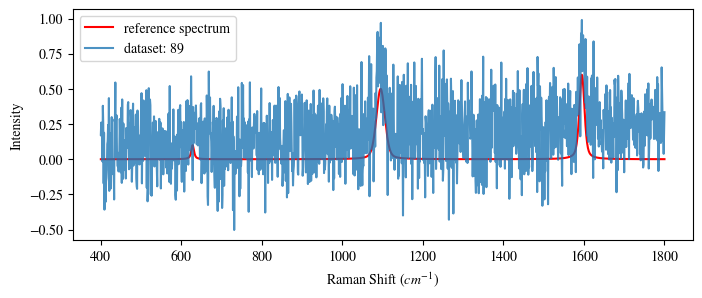

In [4]:
import random
import matplotlib.pyplot as plt

rng = random.Random()
idx = rng.randint(0, 100)

plt.figure(figsize=(8, 3))
plt.plot(wavenumbers, ref_spectrum, color='red', label='reference spectrum')
plt.plot(wavenumbers, synthetic_raman_set[idx], label=f"dataset: {idx}", alpha=0.8)
plt.xlabel("Raman Shift ($cm^{-1}$)")
plt.ylabel("Intensity")
plt.legend()
plt.show()

5-pca

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# get a copy from the 100 sets of synthetic raman data
noisy_data = synthetic_raman_set.copy()

# Skip StandardScaler, as the spectrum data is of same unit, and the magnitude means spectra intensity 
# PCA Reconstruction for Denoising, pca.fit_transform always center the dataset, but not scaling
# Using 5 components to capture signals while filtering variance from noise
pca = PCA(n_components=5)
pca_transformed = pca.fit_transform(noisy_data)

# calculate back, and reconstruct the spectra data
# denoised_data = pca_transformed @ pca.components_ + pca.mean_
denoised_data = pca.inverse_transform(pca_transformed)

6-Understanding the math behind `inverse_transform`
* with the `noisy_data` $X \in \mathbb{R}^{100 \times 1400}$ (100 spectra, each with 1400 features)
* `pca.fit_transform` will center the data first $X_{\text{centered}} = X - \mu$
* Internally, PCA keeps
  * `pca.components_` = $W_{k=5}^T$
  * `pca.mean_` = $\mu$
* then, `pca.fit_transform` selects the top 5 Principal Components
  * from the full eigenspace $ W \in \mathbb{R}^{1400 \times 1400}$
  * select the top 5 principal directions matrix: $ W_{k=5} \in \mathbb{R}^{5 \times 1400}$
  * Then transforms: $Z = X_{\text{centered}} \cdot W_{k=5}^T$
    * $Z = (X - \mu) W_{k=5}^T$
* we got $Z \in \mathbb{R}^{100 \times 5}$ → your `pca_transformed`
  * Dimensions: $(100 \times 1400) \cdot (1400 \times 5) = (100 \times 5)$
* `inverse_transform` maps $Z$ back to rank-5 approximation $\hat{X}$ with $\hat{X} = Z \cdot W_{k=5} + \mu$
  * $Z \in \mathbb{R}^{100 \times 5}$
  * $W_{k=5} \in \mathbb{R}^{5 \times 1400}$
  * $\hat{X} \in \mathbb{R}^{100 \times 1400}$
  * Dimensions: $(100 \times 5) \cdot (5 \times 1400) + (1 \times 1400) = (100 \times 1400)$
* all in one: $\hat{X} =[(X - \mu) W_{k=5}^T]W_{k=5} + \mu$
* The Loss of Information: It is worth noting that $\hat{X}$ is a rank-5 approximation of the original $X$.
  * It keeps only the variance aligned with those 5 components and discards everything else (the "noise").

```python
# in code
denoised_data = pca_transformed @ pca.components_ + pca.mean_
```

7-understanding $W_k$ (the `pca.components_` matrix of size $5 \times 1400$) has orthonormal rows.
* The Identity Property: $W_{k=5} W_{k=5}^T = I_{k=5}$
  * Since the rows (principal components) are unit vectors and are orthogonal to each other, multiplying $W_{k=5}$ by its transpose results in a $5 \times 5$ Identity Matrix.
  * This confirms that the transformation to the reduced space preserves the coordinate system's integrity for those 5 dimensions.
* The Projection Property: $W_{k=5}^T W_{k=5} = P$
  * $W_{k=5}^T W_{k=5} \neq I$.
  * Instead, it results in a $1400 \times 1400$ Projection Matrix ($P$).
* When you calculate $\hat{X} = (X - \mu) W_{k=5}^T W_{k=5} + \mu$, you are essentially multiplying the centered data by this projection matrix $P$.
  * $P$ projects the data onto the 5-dimensional subspace.
  * Any variance in $X$ that was perpendicular to that subspace is multiplied by zero and "dropped," which is how the denoising occurs.

 Summary Table
| Operation | Resulting Matrix Size | Interpretation |
| :--- | :--- | :--- |
| $W_{k=5} W_{k=5}^T$ | $5 \times 5$ | Identity: Confirms components are orthonormal. |
| $W_{k=5}^T W_{k=5}$ | $1400 \times 1400$ | Projection: Filters data to keep only the top 5 dimensions. |


8-plot to compare
* reference spectrum
* a randomly picked noise spectrum
* the same noise spectrum treated with PCA, as denoised

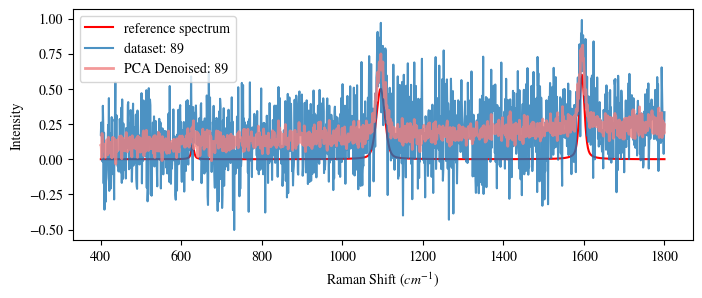

In [6]:
plt.figure(figsize=(8, 3))

plt.plot(wavenumbers, ref_spectrum, color='red', label='reference spectrum')
plt.plot(wavenumbers, synthetic_raman_set[idx], label=f"dataset: {idx}", alpha=0.8)
plt.plot(wavenumbers, denoised_data[idx], label=f"PCA Denoised: {idx}", color='lightcoral', lw=2, alpha=0.8)
plt.xlabel("Raman Shift ($cm^{-1}$)")
plt.ylabel("Intensity")
plt.legend()
plt.show()

9-Deep Learning, with 1D Convolutional Autoencoder (1D-CAE)
* compared to PCA
  * PCA reduces the noise signal by selecting principal components
  * and then re-construct the spectrum through inverse-transform
* 1D-Convolutional Autoencoder (1D-CAE) includes both an Encoder and a Decoder.
  * The Encoder creates the mapping $z = f(x)$, where $z$ is the latent space.
    * `encoded = layers.MaxPooling1D(2, padding='same')(x)`, (350, 16)
    * This is a Feature Extractor (the latent space)
    * or a Classifier, (need a "Dense" layer to turn it into a classifier)
  * The Decoder creates the mapping $x' = g(z)$, (1400, 1)
    * This 'hallucinate' or reconstructs the clean synthetic Raman spectra.
  * And both the  $z = f(x)$ and $x' = g(z)$ are realized through Gradient Descent loss minimization.

For denoising, 1D-CAE goes through this process
  * Input → Encoder → Latent Space → Decoder → Denoised Output


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_denoising_autoencoder(input_shape=(1400, 1)):
    input_img = layers.Input(shape=input_shape)

    # Encoder: Downsampling to capture peak features
    x = layers.Conv1D(32, 3, activation='relu', padding='same', name='encoder_conv1d_0')(input_img)
    x = layers.MaxPooling1D(2, padding='same')(x)
    x = layers.Conv1D(16, 3, activation='relu', padding='same', name='encoder_conv1d_1')(x)
    encoded = layers.MaxPooling1D(2, padding='same')(x)

    # Decoder: Upsampling back to 1400
    # mirror the encoder layers
    # UpSampling1D(2): just duplicate to fill two spots
    x = layers.Conv1D(16, 3, activation='relu', padding='same', name='decoder_conv1d_2')(encoded)
    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(32, 3, activation='relu', padding='same', name='decoder_conv1d_3')(x)
    x = layers.UpSampling1D(2)(x)
    
    
    # Final layer: 1 filter to match the input channel
    decoded = layers.Conv1D(1, 3, activation='linear', padding='same', name='decoder_conv1d_4')(x)
    
    autoencoder = models.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

# Prepare data: (100, 1400) -> (100, 1400, 1)
X_noisy = noisy_data.reshape(-1, 1400, 1)
X_ref = np.tile(ref_spectrum, (100, 1)).reshape(-1, 1400, 1)

# Build the DL Model with above funciton
model = build_denoising_autoencoder()

# Here, the synthetic Reference X_ref is used
# That's the reason for the perfect overlap of DL-denoised and reference-spectrum

model.fit(X_noisy, X_ref, epochs=50, batch_size=10, verbose=0)

denoised_data_dl = model.predict(X_noisy).reshape(100, 1400)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


10-plot to compare
* reference spectrum
* a randomly picked noise spectrum
* the same noise spectrum treated with PCA, as denoised
*  the same noise spectrum denoised with Deep Learning (1D-CAE)

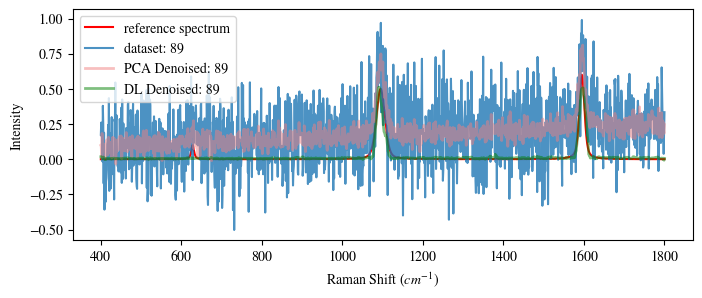

In [11]:
plt.figure(figsize=(8, 3))

plt.plot(wavenumbers, ref_spectrum, color='red', label='reference spectrum')
plt.plot(wavenumbers, synthetic_raman_set[idx], label=f"dataset: {idx}", alpha=0.8)
plt.plot(wavenumbers, denoised_data[idx], label=f"PCA Denoised: {idx}", color='lightcoral', lw=2, alpha=0.5)
plt.plot(wavenumbers, denoised_data_dl[idx], label=f"DL Denoised: {idx}", color='green', lw=2, alpha=0.5)
plt.xlabel("Raman Shift ($cm^{-1}$)")
plt.ylabel("Intensity")
plt.legend()
plt.show()

In [12]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 1400, 1)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_conv1d_0 (Conv1D)            │ (None, 1400, 32)            │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 700, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_conv1d_1 (Conv1D)            │ (None, 700, 16)             │           1,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 350, 16)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_conv1d_2 (Conv1D)            │ (None, 350, 16)             │             784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling1d_2 (UpSampling1D)       │ (None, 700, 16)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_conv1d_3 (Conv1D)            │ (None, 700, 32)             │           1,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling1d_3 (UpSampling1D)       │ (None, 1400, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_conv1d_4 (Conv1D)            │ (None, 1400, 1)             │              97 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,389 (48.40 KB)

 Trainable params: 4,129 (16.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,260 (32.27 KB)

11-Understanding Encoder: `Conv1D`: `x = layers.Conv1D(32, 3, activation='relu', padding='same', name='encoder_conv1d_0')(input_img)`
* `Conv1D(filter = 32, kernel_size=3, activation = 'relu')`
  * 32 filters (sliding windows), each with 3 kernels/weights [x₁, x₂, x₃]
  * each filter sides through the `input_img` with this: z= f(x) = w₁·x₁ + w₂·x₂ + w₃·x₃ + b
  * and the `relu`: max(0, z)
* `padding='same'`, adding 0 to head and tail
  * Input:   [x₁ x₂ x₃ x₄]
  * Padded:  [0 x₁ x₂ x₃ x₄ 0]
* thus, the input is (batch, 1400, 1), and the output is (batch, 1400, 32)

12-Understanding Decoder: `decoded = layers.Conv1D(1, 3, activation='linear', padding='same', name='decoder_conv1d_4')(x)`
* reconstruct the upscaled (batch, 1400, 32) back to (batch, 1400, 1)
* `activation='linear'` Linear activation ($f(x) = x$)
  * The `UpSampling1D` just duplicates points, this creates staircase dataset [5, 5, 8, 8]
  * We need a final interpolator (`kernel = 3`), to check the stairs [5, 5, 8], [5, 8, 8], and then smooth them out into a continuous, realistic-looking Raman peak.

This should end the notes for Mathmatics for Machine Learning. I'll move onto DevOps and TensorFlow2.

### In the End, random timbits

### Apr-01-2026
* Consider a seperate notebook for Find&Replacement, the big mass of `**` power missing

#### Some common Regex for Latex
* `\n={2,}\n`
* `^\[$`